# Проект: Прогнозирование температуры звезды

## Введение

Современная астрономия активно использует закон физики и спектральный анализ для оценки температуры поверхности звёзд. Классические методы основаны на физических законах, но сильно упрощают реальность игнорируя важные особенности, такие как тип звезды, химический состав атмосферы звезды, межзвёздная пыль и поглощение света, линии поглощения в спектре.

С развитием технологий машинного обучения появилась возможность прогнозировать температуру звёзд с помощью нейронных сетей, которые могут выявлять нелинейные зависимости, не описанные формулами.

Обсерватория «Небо на ладони» хочет внедрить технологии машинного обучения для предсказания температуры звёзд, надеясь, что этот метод будет наиболее точным и удобным.

## Цель исследования

Разработать и обучить нейронную сеть, способную прогнозировать абсолютную температуру на поверхности звезды по её характеристикам (светимость, радиус, звёздная величина, цвет и тип). Метрика RMSE не должна превышать 4500.

## Описание данных

В распоряжении имеется база данных обсерватории «Небо на ладони», содержащая сведения о 240 звёздах. Для каждой звезды представлены следующие характеристики:

* Относительная светимость L/Lo — светимость звезды относительно Солнца.
* Относительный радиус R/Ro — радиус звезды относительно радиуса Солнца.
* Абсолютная звёздная величина Mv — физическая величина, характеризующая блеск звезды.
* Звёздный цвет (white, red, blue, yellow, yellow-orange и др.) — цвет звезды, который определяют на основе спектрального анализа.
* Тип звезды.
* Абсолютная температура (T(K)) — температура поверхности звезды в Кельвинах (целевой признак).

## План исследования

* [Загрузка данных](#link1)
* [Предобработка данных](#link2)
* [Создание признаков](#link3)
* [Исследовательский анализ](#link4)
* [Корреляционный анализ](#link5)
* [Построение базовой нейронной сети](#link6)
* [Улучшение нейронной сети](#link7)
* [Общий вывод](#link8)

## Подготовка рабочего пространства

In [1]:
# установим необходимые библотеки
!pip install phik -q

# импортируем необходимые библиотеки
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import phik
from phik import resources
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import math
import random
import torch.utils.data as data
import re
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# импортируем функции из моего модуля
from ds_lib_tatarnikov import (
    data_overview,
    to_snake_case,
    show_plot,
    print_corr_levels,
    show_bar_cat_feature 
)

# зададим константы
RANDOM_STATE = 42
TEST_SIZE = 0.25

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)  
torch.cuda.manual_seed_all(SEED)  
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

<a class='anchor' id="link1"></a>
## 1 Загрузка данных

**1.1 Откроем файл с данными**

In [2]:
try:
    df = pd.read_csv('6_class.csv', index_col=0)
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/6_class.csv', index_col=0)

**1.2 Изучим общую информацию о датафрейме**

Выведем первые строки и общую информацию о датафрейме.

In [3]:
data_overview(df, "с данными о звездах")

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color
0,3068,0.002400,0.1700,16.12,0,Red
1,3042,0.000500,0.1542,16.60,0,Red
2,2600,0.000300,0.1020,18.70,0,Red
3,2800,0.000200,0.1600,16.65,0,Red
4,1939,0.000138,0.1030,20.06,0,Red


<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 13.1+ KB

Таблица с данными о звездах состоит из 240 строк и 6 столбцов.
Пропусков нет.


Столбцы "тип звезды" и "цвет звезды" нужно привести к типу "category". Названия столбцов нужно привести к змеинному типу.

<a class='anchor' id="link2"></a>
## 2 Предобработка данных

**2.1 Приведение к змеинному типу**

Сделаем рабочую копию датасета и приведем названия столбцов к змеиному стилю.

In [4]:
df_prepared = df.copy()
df_prepared.columns = [to_snake_case(col) for col in df_prepared.columns]
df_prepared.head()

,temperature_k,luminosity_l_lo,radius_r_ro,absolute_magnitude_mv,star_type,star_color
0,3068,0.002400,0.1700,16.12,0,Red
1,3042,0.000500,0.1542,16.60,0,Red
2,2600,0.000300,0.1020,18.70,0,Red
3,2800,0.000200,0.1600,16.65,0,Red
4,1939,0.000138,0.1030,20.06,0,Red


**2.2 Поиск дубликатов**

In [5]:
temp = df_prepared.duplicated().sum()
print(f"Имеется {temp} явных дубликатов.")

Имеется 0 явных дубликатов.


**2.3 Поиск неявных дубликатов**

Посмотрим на уникальные значения в столбце с названиями цветов.

In [6]:
df_prepared['star_color'].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'Blue ',
       'yellowish', 'Yellowish', 'Orange-Red', 'Blue white ',
       'Blue-White'], dtype=object)

Встречаются разные варианты написания одних и тех же цветов. Приведем все цвета к нижнему регистру, удалим лишние пробелы, и разные написания приведем к одному значению. Оттенки одинаковых цветов объединим в один цвет.

In [7]:
df_prepared['star_color'] = df_prepared['star_color'].apply(to_snake_case)
df_prepared['star_color'] = df_prepared['star_color'].replace({"whitish": "white"})
df_prepared['star_color'] = df_prepared['star_color'].replace({"white_yellow": "yellow_white"})
df_prepared['star_color'] = df_prepared['star_color'].replace({"yellowish_white": "yellow_white"})
df_prepared['star_color'] = df_prepared['star_color'].replace({"yellowish": "yellow"})
df_prepared['star_color'] = df_prepared['star_color'].replace({"orange_red": "orange"})
df_prepared['star_color'] = df_prepared['star_color'].replace({"pale_yellow_orange": "orange"})
df_prepared['star_color'].unique()

array(['red', 'blue_white', 'white', 'yellow_white', 'orange', 'blue',
       'yellow'], dtype=object)

**2.4 Приведение типов**

Столбцы "тип звезды" и "цвет звезды" приведем к типу "category".

In [8]:
df_prepared['star_type'] = df_prepared['star_type'].astype('category')
df_prepared['star_color'] = df_prepared['star_color'].astype('category')
df_prepared.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   temperature_k          240 non-null    int64   
 1   luminosity_l_lo        240 non-null    float64 
 2   radius_r_ro            240 non-null    float64 
 3   absolute_magnitude_mv  240 non-null    float64 
 4   star_type              240 non-null    category
 5   star_color             240 non-null    category
dtypes: category(2), float64(3), int64(1)
memory usage: 10.4 KB


**Промежуточный итог:**

Данные предобработаны и подготовленны для дальнейшего анализа.

<a class='anchor' id="link3"></a>
## 3 Создание признаков

**3.1 Спектр звезды**

Цвет звезды определяется спектром, в котором звезда испускает максимум излучения. Это важно учитывать, так как по закону Вина, чем выше температура тела, тем короче длина волны излучения и тем смещённее спектр в сторону синего.
Формула закона смещения Вина:

$$
\lambda_{\text{max}} = \frac{b}{T}
$$
где:  
- $\lambda_{\text{max}}$ — длина волны максимального излучения (м)  
- $T$ — абсолютная температура тела (К)  
- $b$   — постоянная Вина $(b \approx 2.897 \cdot 10^{-3} \, \text{м·К})${м·К}\))

Вот общая зависимость:
| Цвет звезды       | Температура (примерно) |
|--------------------|-------------------------|
| **Синий**          | 25 000 – 50 000 K      |
| **Голубой**        | 10 000 – 25 000 K      |
| **Белый**          | 7 500 – 10 000 K       |
| **Белый-жёлтый**   | 6 000 – 7 500 K        |
| **Жёлтый**         | 5 000 – 6 000 K        |
| **Оранжевый**      | 3 500 – 5 000 K        |
| **Красный**        | 2 000 – 3 500 K        |

Поэтому цвет звезды является порядковым категориальным признаком. Добавим признак "спектральный класс" и пронумеруем цвета от красного до синего. По закону смещения Вина температура звезды будет прямо зависить от значения категории.

In [9]:
color_to_spectral_class = {
    "blue": 7,              # Синий
    "blue_white": 6,        # Голубой
    "white": 5,             # Белый
    "yellow_white": 4,      # Белый-жёлтый
    "yellow": 3,            # Жёлтый
    "orange": 2,            # Оранжевый
    "red": 1,               # Красный
}

In [10]:
df_prepared['spectral_class'] = df_prepared['star_color'].replace(color_to_spectral_class)

In [11]:
df_prepared.tail(5)

,temperature_k,luminosity_l_lo,radius_r_ro,absolute_magnitude_mv,star_type,star_color,spectral_class
235,38940,374830.0,1356.0,-9.93,5,blue,7
236,30839,834042.0,1194.0,-10.63,5,blue,7
237,8829,537493.0,1423.0,-10.73,5,white,5
238,9235,404940.0,1112.0,-11.23,5,white,5
239,37882,294903.0,1783.0,-7.80,5,blue,7


**3.2 Интенсивность излучения**

Закон Стефана-Больцмана говорит о том, что светимость звезды на единицу ее поверхностной площади пропорциональна температуре поверхности в четвертой степени. Площадь сферы это $4 \pi R^2$. Следовательно можно сделать признак "Корень 4й степени из интенсивности излучения" поделив светимость на квадрат радиуса и взяв из всего корень четвертой степени. Новый признак, по закону Стефана-Больцмана, должен быть пропорционален температуре поверхности звезды.

Закон Стефана–Больцмана:

$$
E = \sigma T^4
$$

где:  
- $E$ — излучаемая мощность на единицу площади поверхности (Вт/м²)  
- $T$ — абсолютная температура тела (К)  
- $\sigma$ — постоянная Стефана–Больцмана ($\sigma \approx 5.67 \cdot 10^{-8} \, \text{Вт·м}^{-2}\text{·К}^{-4})$

Полная формула светимости:
$$
L = 4 \pi R^2 \sigma T^4
$$

Приведём к интенсивности:
$$
\frac{L}{R^2} = 4 \pi \sigma T^4
$$

В относительных единицах (относительно Солнца):
$$
\text{intensity} = \frac{L / L_\odot}{(R / R_\odot)^2}
$$

Приблизительное выражение температуры:
$$
\text{intensity}^{\frac{1}{4}} = (\frac{L / L_\odot}{(R / R_\odot)^2})^{\frac{1}{4}} \sim T
$$

In [12]:
df_prepared['intensity_4r'] = (df_prepared['luminosity_l_lo'] / (df_prepared['radius_r_ro'] ** 2)) ** 0.25

In [13]:
df_prepared.head()

,temperature_k,luminosity_l_lo,radius_r_ro,absolute_magnitude_mv,star_type,star_color,spectral_class,intensity_4r
0,3068,0.002400,0.1700,16.12,0,red,1,0.536820
1,3042,0.000500,0.1542,16.60,0,red,1,0.380803
2,2600,0.000300,0.1020,18.70,0,red,1,0.412079
3,2800,0.000200,0.1600,16.65,0,red,1,0.297302
4,1939,0.000138,0.1030,20.06,0,red,1,0.337716


**Промежуточный итог:**

Добавлен признак "Корень 4й степени из интенсивности излучения", основанный на законе Стефана–Больцмана. Он отражает удельную светимость на единицу площади, что прямопропорционально связано с температурой звезды.

Добавлен признак "Спектральный класс", отражающий корреляцию цвета звезды и ее температуры по закону смещения Вина.

<a class='anchor' id="link4"></a>
## 4 Исследовательский анализ данных

Для понятной визуализации информации запишем названия признаков на русском языке.

In [14]:
eng_to_rus = {
    # Признаки
    "temperature_k": "Температура (K)",
    "luminosity_l_lo": "Светимость (L/Lo)",
    "radius_r_ro": "Радиус (R/Ro)",
    "absolute_magnitude_mv": "Абсолютная звёздная величина (Mv)",
    "star_color": "Цвет звезды",
    "star_type": "Тип звезды",
    "spectral_class": "Спектральный класс",	
    "intensity_4r": "Интенсивность излучения (в 1/4 степени)",

    # Цвета
    "red": "Красный",
    "blue_white": "Голубовато-белый",
    "white": "Белый",
    "blue": "Синий",
    "yellow_white": "Жёлто-белый",
    "orange": "Оранжевый",
    "yellow": "Желтый"
}

Также для визуализации раскодируем названия типов звезд.

In [15]:
star_type_dict = {
    0: "Коричневый карлик",
    1: "Красный карлик",
    2: "Белый карлик",
    3: "Звезды главной последовательности",
    4: "Сверхгигант",
    5: "Гипергигант"
}

Создадим копию датафрейма, переведем его на русский язык и раскодируем названия типов звезд.

In [16]:
df_rus = df_prepared.copy()
df_rus.rename(columns=eng_to_rus, inplace=True)
df_rus = df_rus.replace(eng_to_rus)
df_rus['Тип звезды'] = df_rus['Тип звезды'].map(star_type_dict)
df_rus.sample(5)

,Температура (K),Светимость (L/Lo),Радиус (R/Ro),Абсолютная звёздная величина (Mv),Тип звезды,Цвет звезды,Спектральный класс,Интенсивность излучения (в 1/4 степени)
24,16500,0.01300,0.014,11.89,Белый карлик,Голубовато-белый,6,2.853789
6,2637,0.00073,0.127,17.22,Коричневый карлик,Красный,1,0.461242
93,4980,0.35700,1.130,4.78,Звезды главной последовательности,Желтый,3,0.727156
109,33421,352000.00000,67.000,-5.79,Сверхгигант,Синий,7,2.975762
104,11096,112000.00000,12.000,-5.91,Сверхгигант,Синий,7,5.280972


**4.1 Статистический анализ**

Посмотрим статистическое описание данных.

In [17]:
df_rus.describe(include='all')

,Температура (K),Светимость (L/Lo),Радиус (R/Ro),Абсолютная звёздная величина (Mv),Тип звезды,Цвет звезды,Спектральный класс,Интенсивность излучения (в 1/4 степени)
count,240.000000,240.000000,240.000000,240.000000,240,240,240.000000,240.000000
unique,NaN,NaN,NaN,NaN,6,7,NaN,NaN
top,NaN,NaN,NaN,NaN,Коричневый карлик,Красный,NaN,NaN
freq,NaN,NaN,NaN,NaN,40,112,NaN,NaN
mean,10497.462500,107188.361635,237.157781,4.382396,NaN,NaN,3.645833,1.633864
std,9552.425037,179432.244940,517.155763,10.532512,NaN,NaN,2.648830,1.702780
min,1939.000000,0.000080,0.008400,-11.920000,NaN,NaN,1.000000,0.167381
25%,3344.250000,0.000865,0.102750,-6.232500,NaN,NaN,1.000000,0.494924
50%,5776.000000,0.070500,0.762500,8.313000,NaN,NaN,4.000000,0.843726
75%,15055.500000,198050.000000,42.750000,13.697500,NaN,NaN,6.000000,2.163815


В ходе осмотра статистических данных не было обнаружено каких либо аномалий. Медианные значения и межквартильные размахи количественных данных соответствуют диапазонам данных. Подробнее посмотрим на данные в процессе визуализации. 

**4.2 Визуализация статистических данных**

In [18]:
rus_cat_features = ['Тип звезды', 'Цвет звезды', 'Спектральный класс']
rus_num_features = ['Светимость (L/Lo)', 'Радиус (R/Ro)', 'Абсолютная звёздная величина (Mv)', 'Интенсивность излучения (в 1/4 степени)']
rus_target_feature = 'Температура (K)'

Для количественных признаков и целевого признака построим гистограммы и диаграммы размаха.

Для категориальных данных построим столбчатые диаграммы частот.

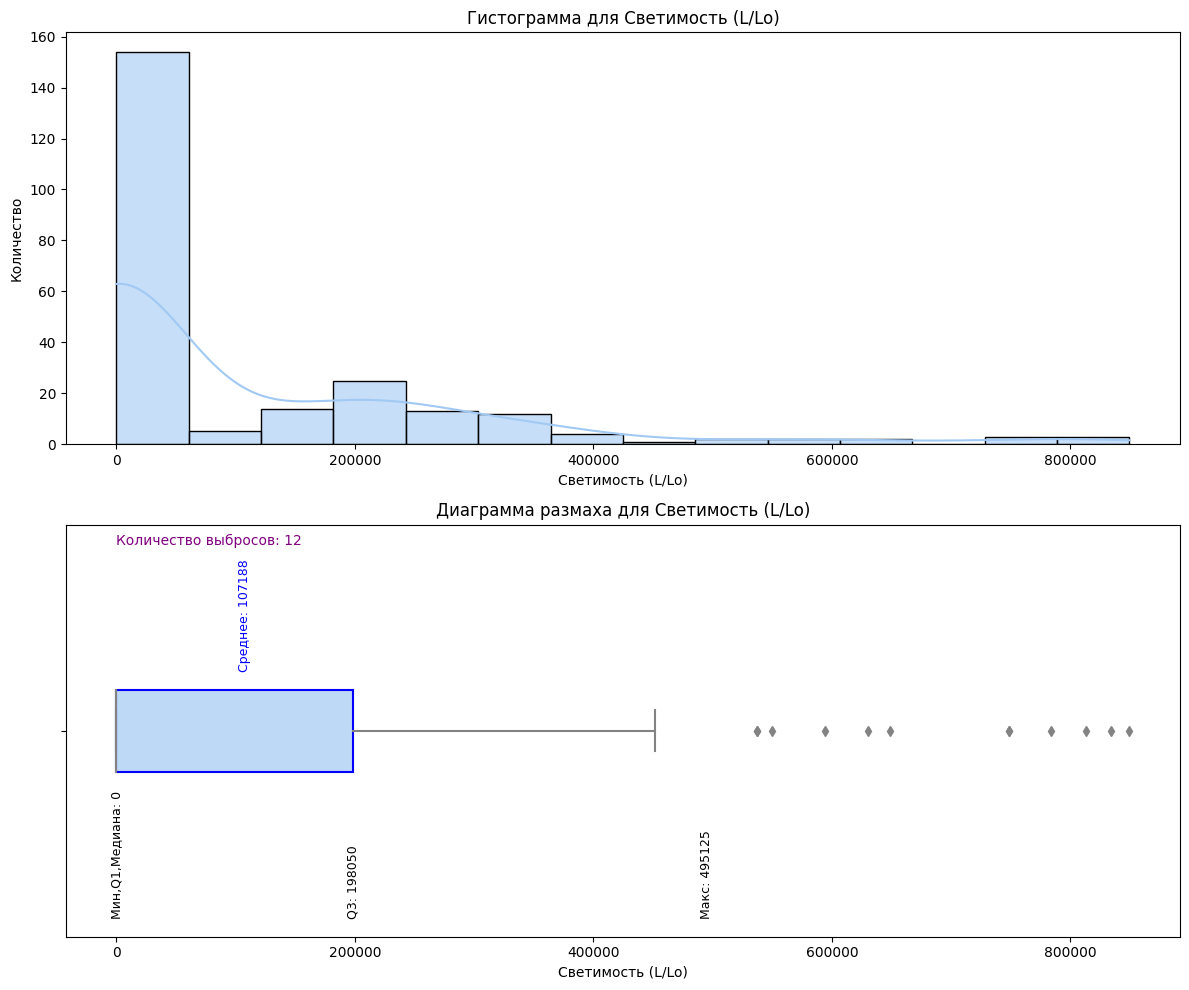

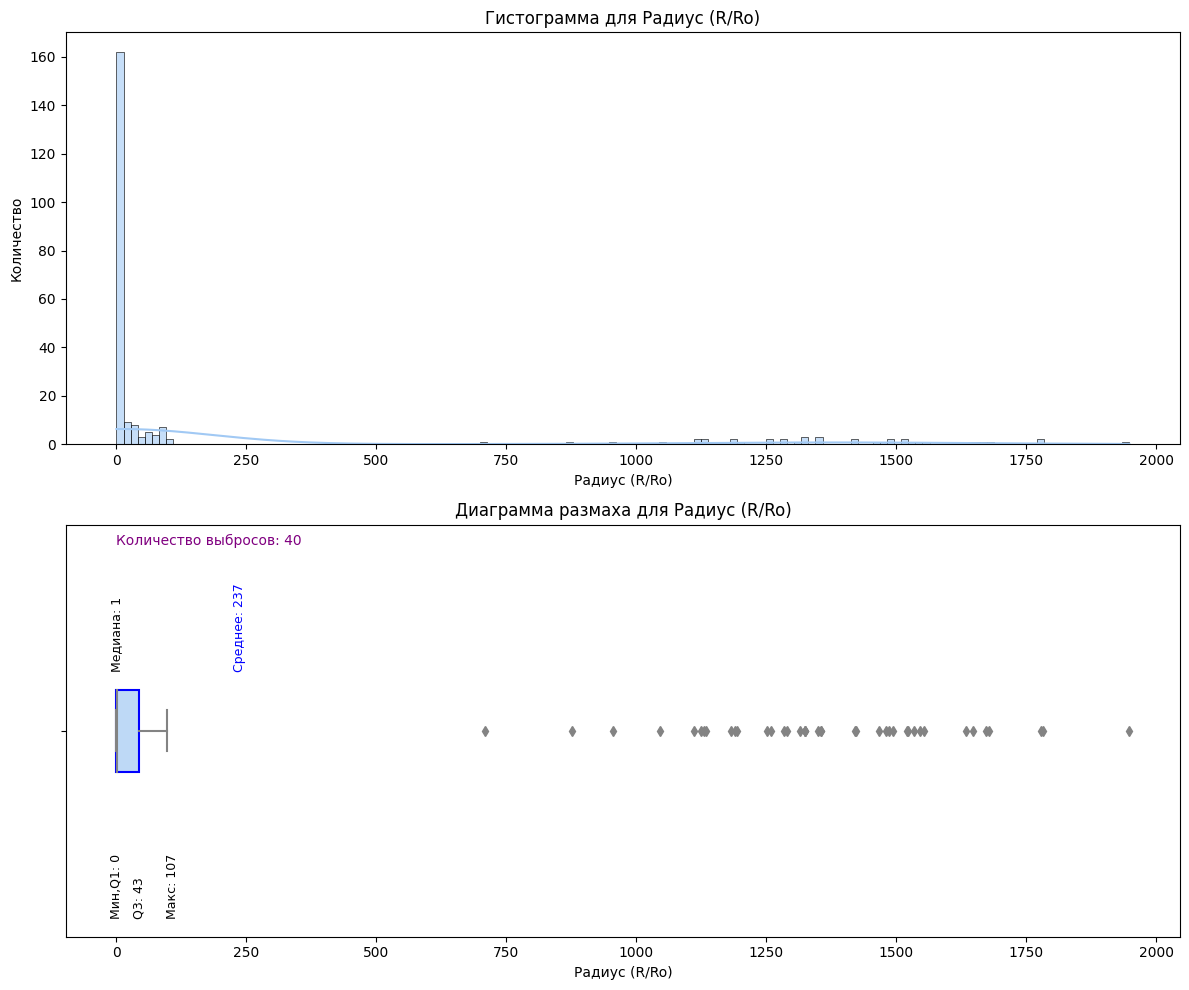

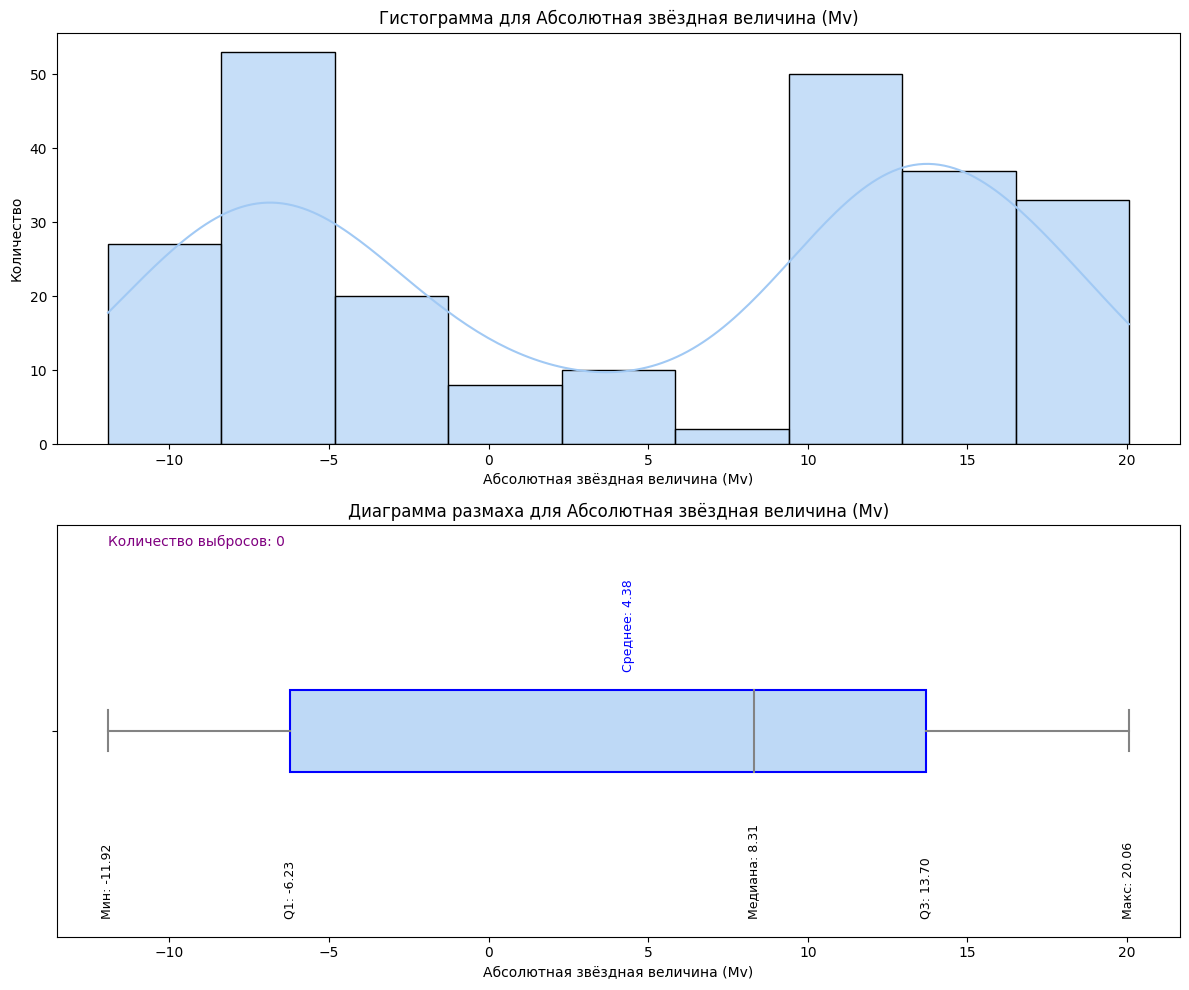

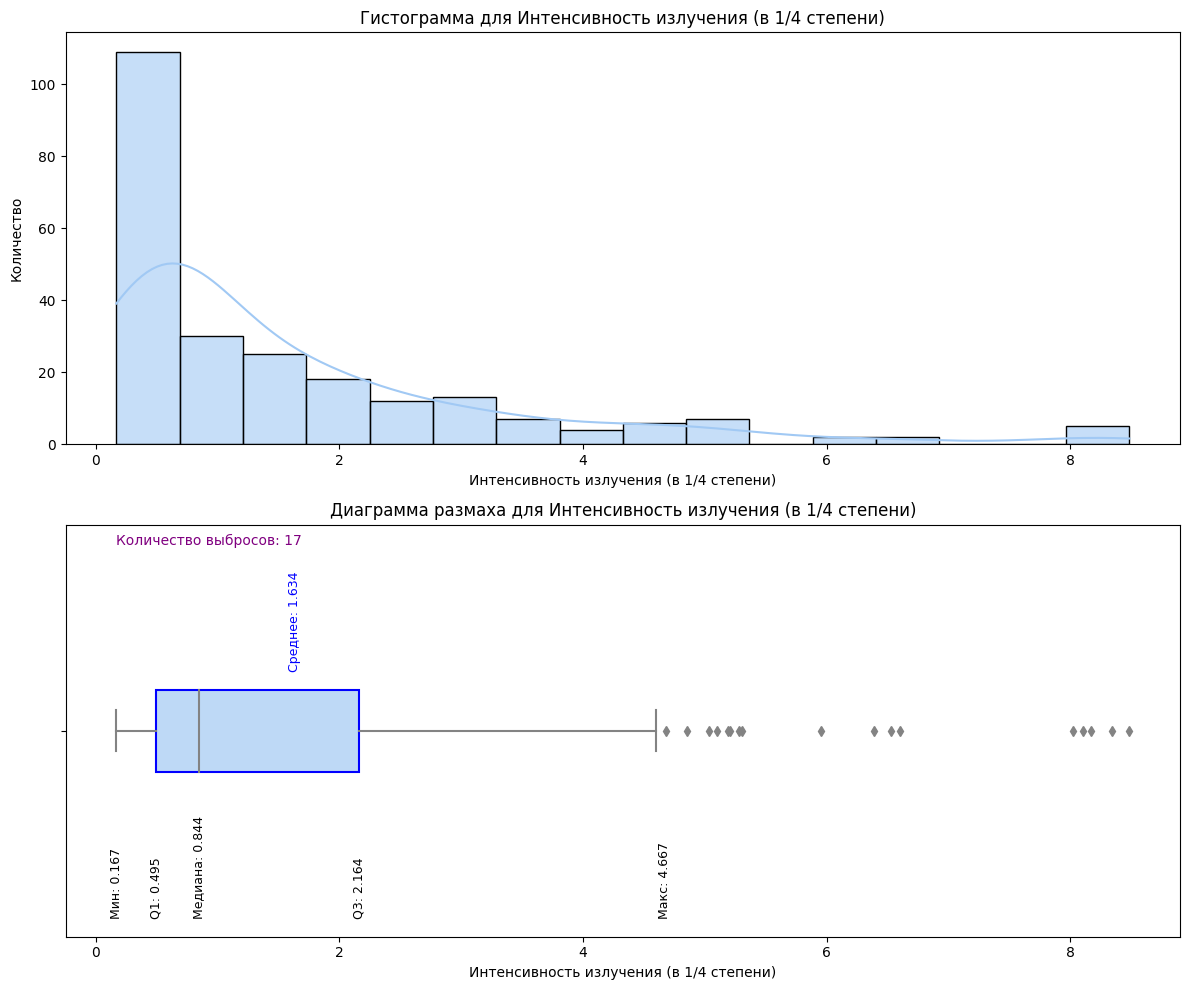

In [19]:
for feature in rus_num_features:
    show_plot(df_rus, feature)

Гистограмма радиусов сильно сжата в районе малых значений. Построим гистограмму и диаграмму размаха в логарифмическом масштабе.

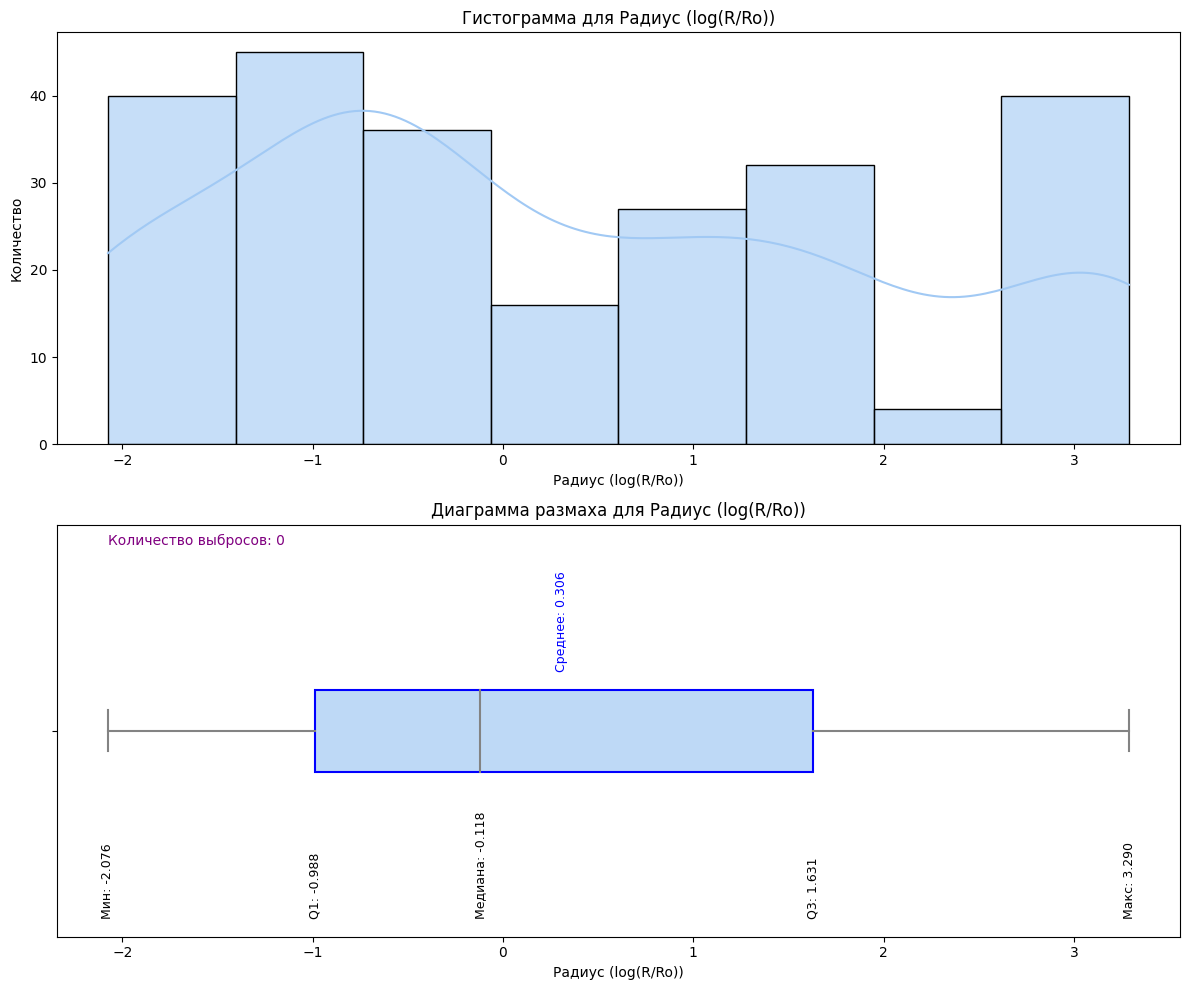

In [20]:
df_rus['Радиус (log(R/Ro))'] = np.log10(df_rus['Радиус (R/Ro)'])
show_plot(df_rus, 'Радиус (log(R/Ro))', new_bins=8)

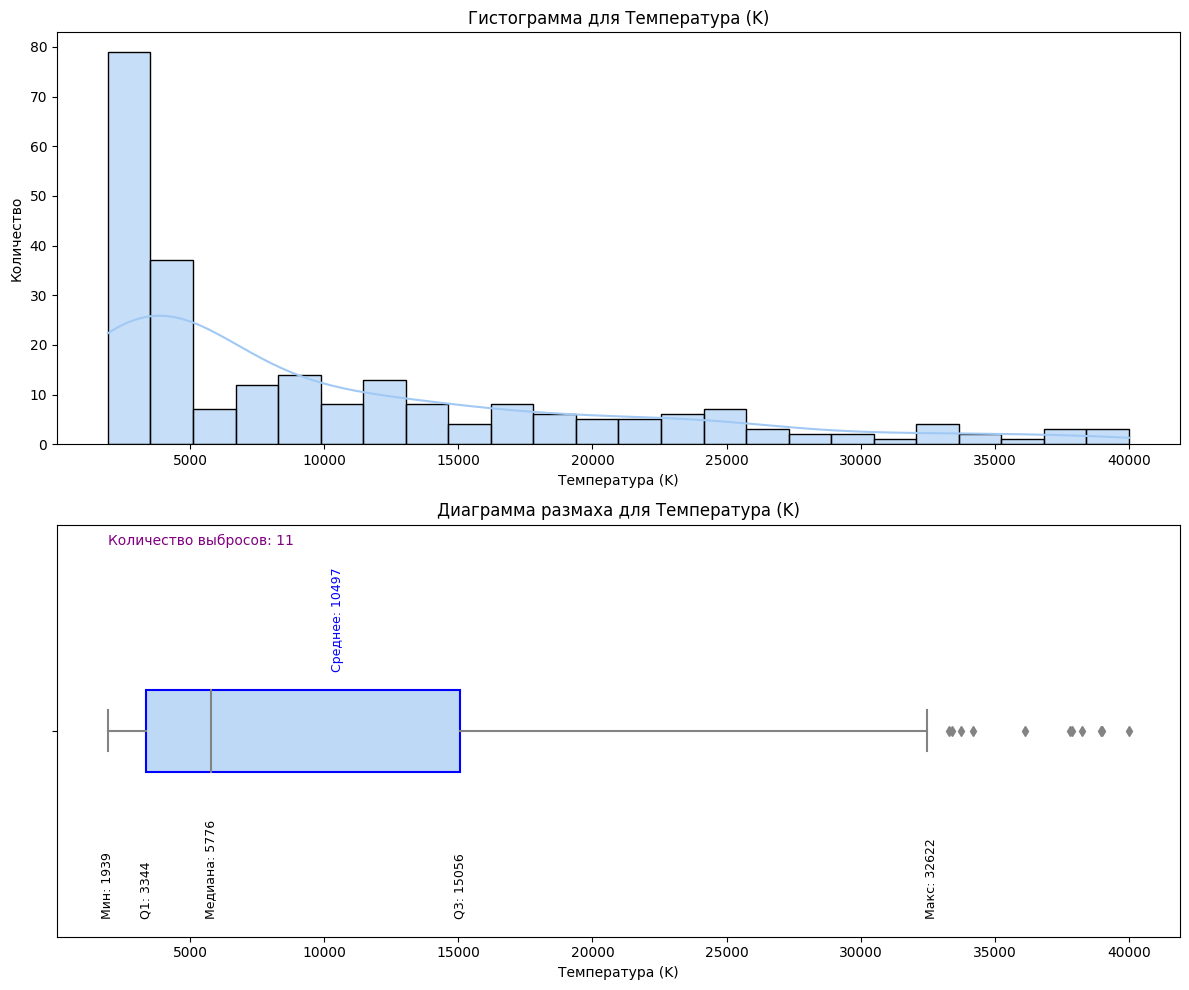

In [21]:
show_plot(df_rus, rus_target_feature, new_bins=24)

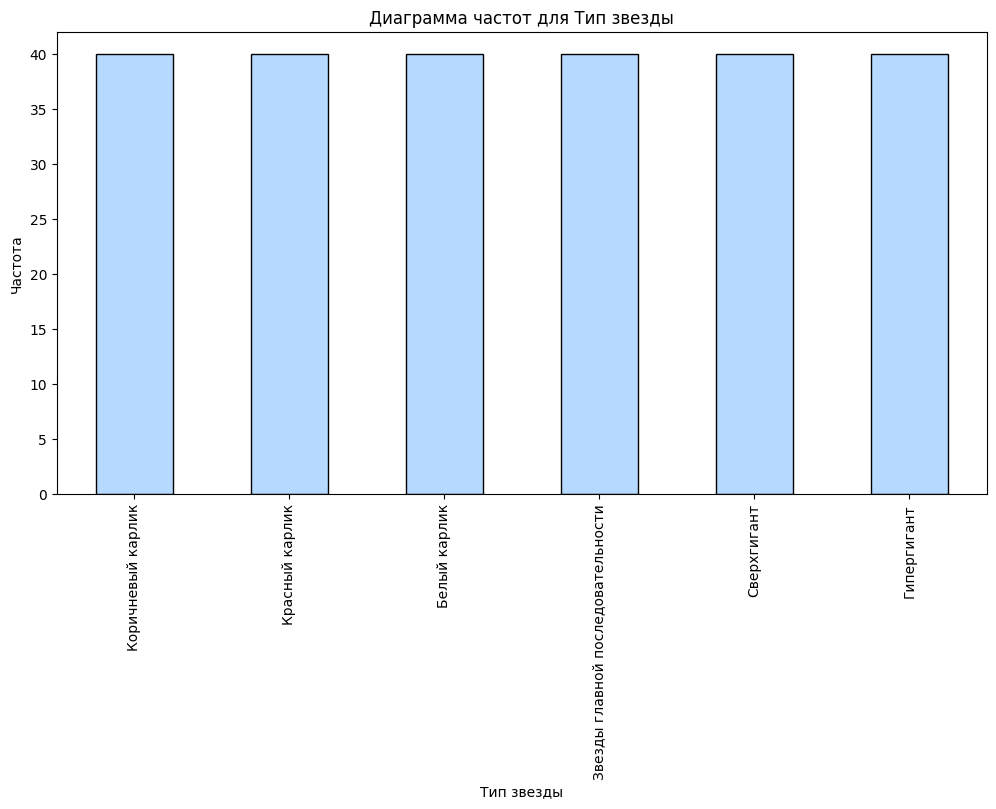

In [22]:
show_bar_cat_feature(df_rus, 'Тип звезды')

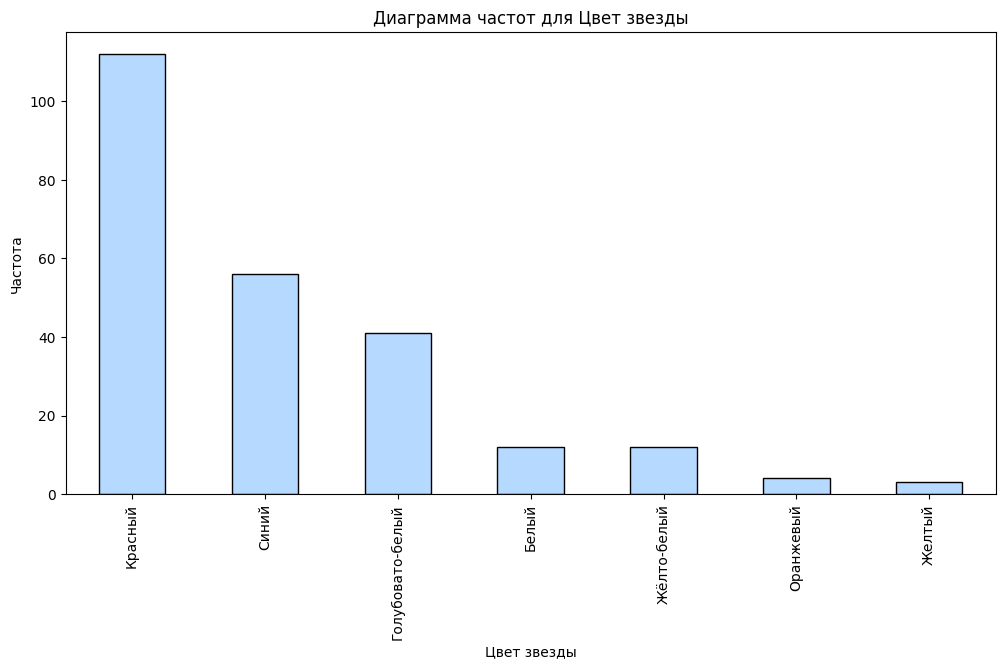

In [23]:
show_bar_cat_feature(df_rus, 'Цвет звезды', sort='values', asc=False)

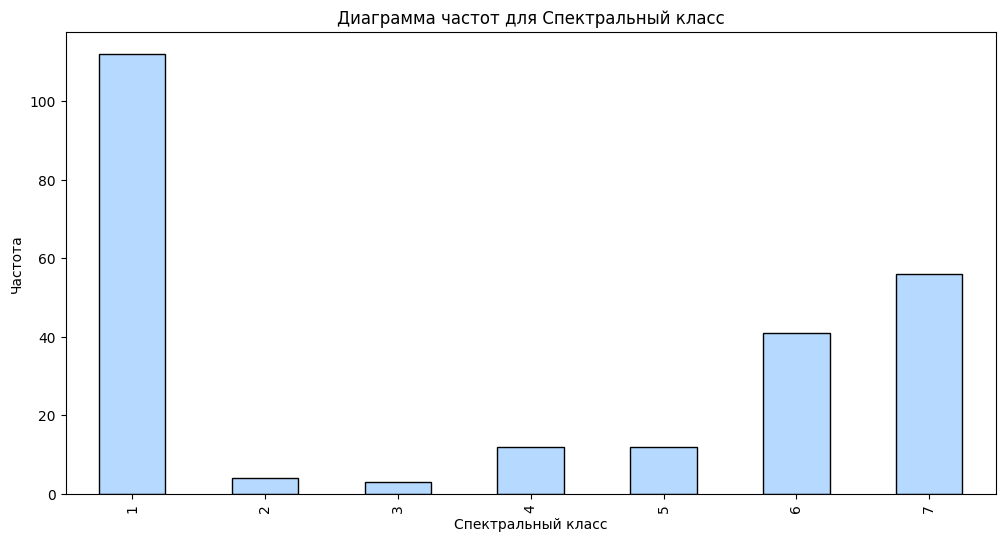

In [24]:
show_bar_cat_feature(df_rus, 'Спектральный класс')

Светимость, Интенсивность излучений в (1/4 степени) и Температура имеют распределение похожее на (1/x). 

Абсолютные звездные величины имеют логарифмический масштаб и в этом масштабе распределение абсолютных звездных величин можно назвать приблизительно равномерным.

Распределение радиусов в логарифмическом масштабе также является приблизительно равномерным.

Представленная выборка звезд стратифицирована по типу. В выборке представлено по 40 звезд каждого типа.

Наибольшее количество звезд в выборке имеют красный цвет. Количество звезд других цветов увеличивается от оранжевого цвета до синего.

Памятка. В реальности количество звезд во вселенной уменьшается от красных к синим, потому что звёзды большой массы, излучающие в синем спектре, рождаются редко и живут мало, а красные звезды (в основном коричневые и красные карлики) появляются често и существуют долго. Но так как предоставленная выборка стратифицирована по типу звезд, распределение имеет обратный вид.

Посмотрим на распределения звезд с учетом их цвета.

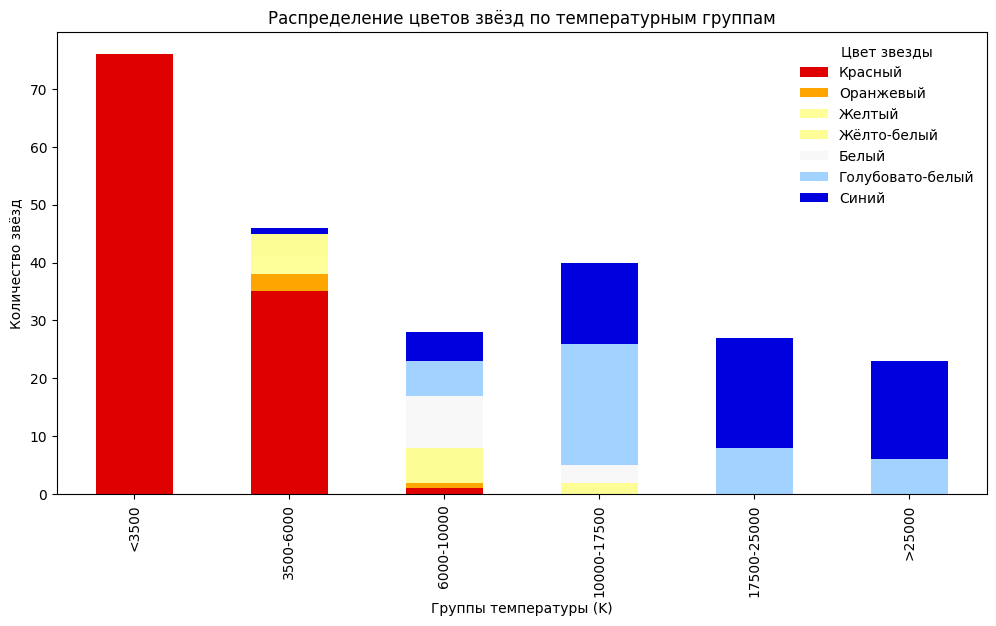

In [25]:
color_palette = {
    'Красный': '#df0000',
    'Голубовато-белый': '#a2d2ff', 
    'Белый': '#f8f8f8',    
    'Синий': '#0000df', 
    'Жёлто-белый': '#fdfd96',
    'Оранжевый': '#ffa500',
    'Желтый': '#ffff99',
}


bins = [0, 3500, 6000, 10000, 17500, 25000, 40000]
labels = ['<3500', '3500-6000', '6000-10000', '10000-17500', '17500-25000', '>25000']
df_rus['Темп. группа'] = pd.cut(df_rus['Температура (K)'], bins=bins, labels=labels)

grouped = df_rus.groupby(['Темп. группа', 'Цвет звезды']).size().unstack(fill_value=0)
# Создаём маппинг цвет → спектральный класс
color_to_class = df_rus.drop_duplicates('Цвет звезды').set_index('Цвет звезды')['Спектральный класс']
# Сортируем столбцы по этому маппингу
grouped = grouped[color_to_class.loc[grouped.columns].sort_values().index]

colors = [color_palette[color] for color in grouped.columns]
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)
plt.xlabel('Группы температуры (K)')
plt.ylabel('Количество звёзд')
plt.title('Распределение цветов звёзд по температурным группам')
plt.legend(title='Цвет звезды', frameon=False)
plt.show()

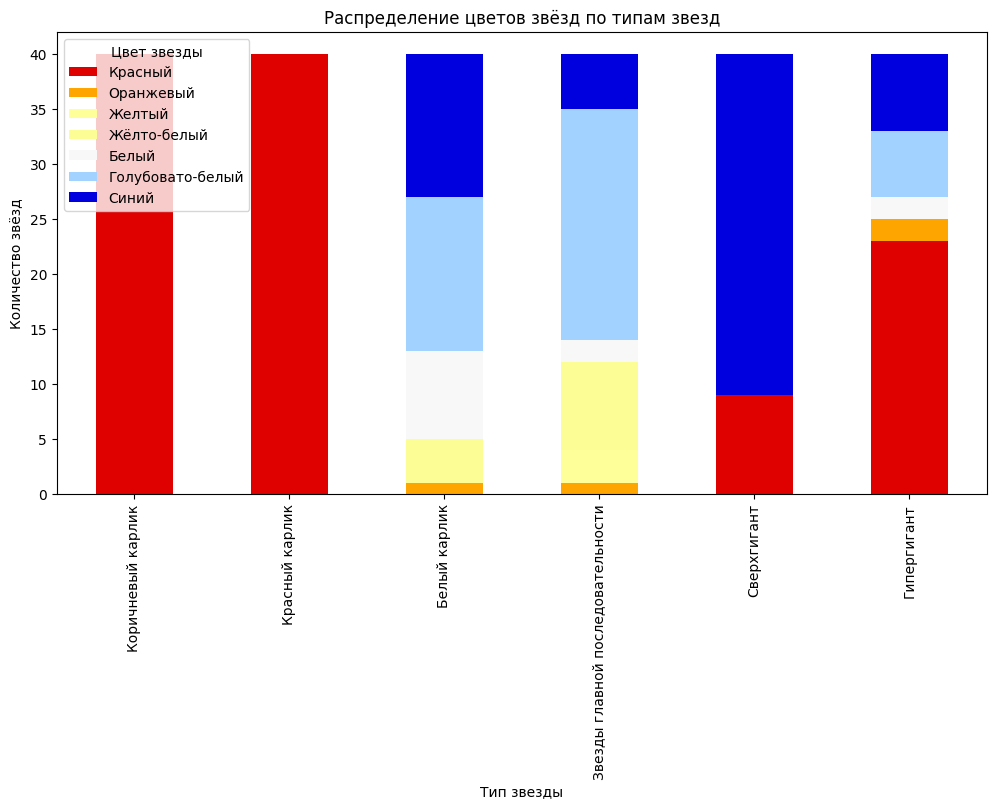

In [26]:
grouped = df_rus.groupby(['Тип звезды', 'Цвет звезды']).size().unstack(fill_value=0)
grouped = grouped[color_to_class.loc[grouped.columns].sort_values().index]
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)
plt.xlabel('Тип звезды')
plt.ylabel('Количество звёзд')
plt.title('Распределение цветов звёзд по типам звезд')
plt.legend(title='Цвет звезды')
plt.show()

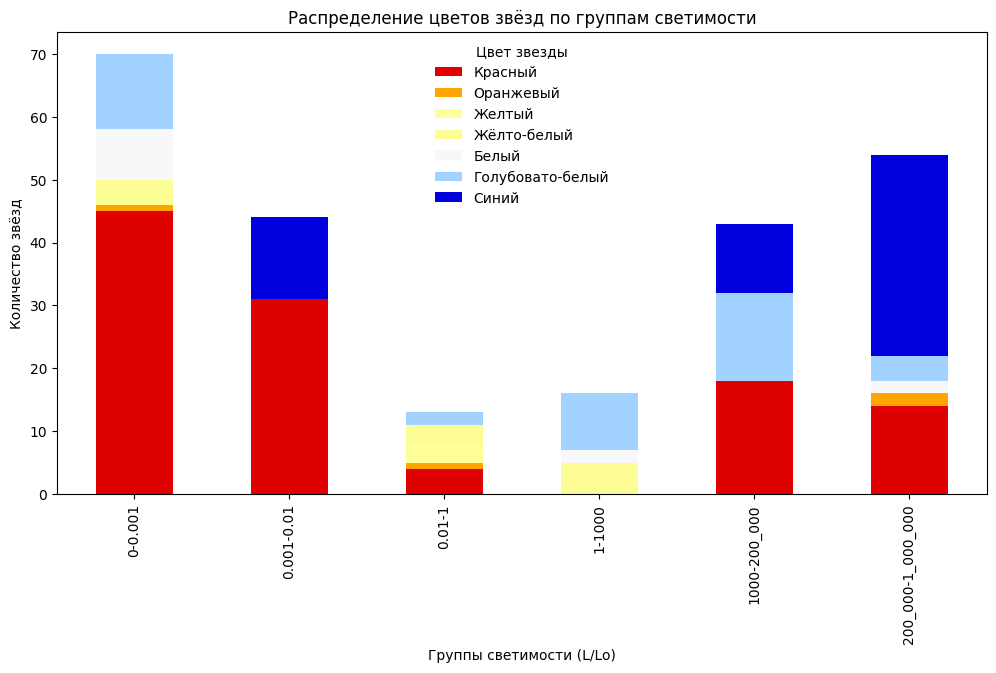

In [27]:
bins_lum = [0, 0.001, 0.01, 1, 1000, 200_000, 1_000_000]
labels_lum = ['0-0.001','0.001-0.01','0.01-1','1-1000','1000-200_000','200_000-1_000_000']
df_rus['Светимость группа'] = pd.cut(df_rus['Светимость (L/Lo)'], bins=bins_lum, labels=labels_lum)

grouped = df_rus.groupby(['Светимость группа', 'Цвет звезды']).size().unstack(fill_value=0)
grouped = grouped[color_to_class.loc[grouped.columns].sort_values().index]

grouped.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)
plt.xlabel('Группы светимости (L/Lo)')
plt.ylabel('Количество звёзд')
plt.title('Распределение цветов звёзд по группам светимости')
plt.legend(title='Цвет звезды', frameon=False)
plt.show()

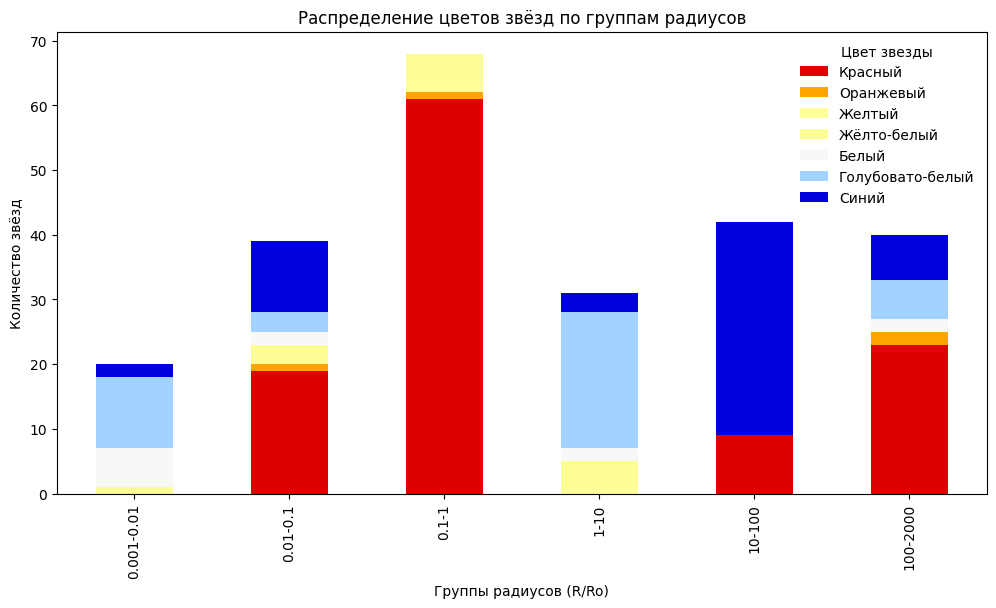

In [28]:
bins = [0.001, 0.01, 0.1, 1, 10, 100, 2000]
labels = ['0.001-0.01','0.01-0.1','0.1-1','1-10','10-100','100-2000']

df_rus['Радиус группа'] = pd.cut(df_rus['Радиус (R/Ro)'], bins=bins, labels=labels, include_lowest=True)

grouped = df_rus.groupby(['Радиус группа', 'Цвет звезды']).size().unstack(fill_value=0)
grouped = grouped[color_to_class.loc[grouped.columns].sort_values().index]

grouped.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)
plt.xlabel('Группы радиусов (R/Ro)')
plt.ylabel('Количество звёзд')
plt.title('Распределение цветов звёзд по группам радиусов')
plt.legend(title='Цвет звезды', frameon=False)
plt.show()

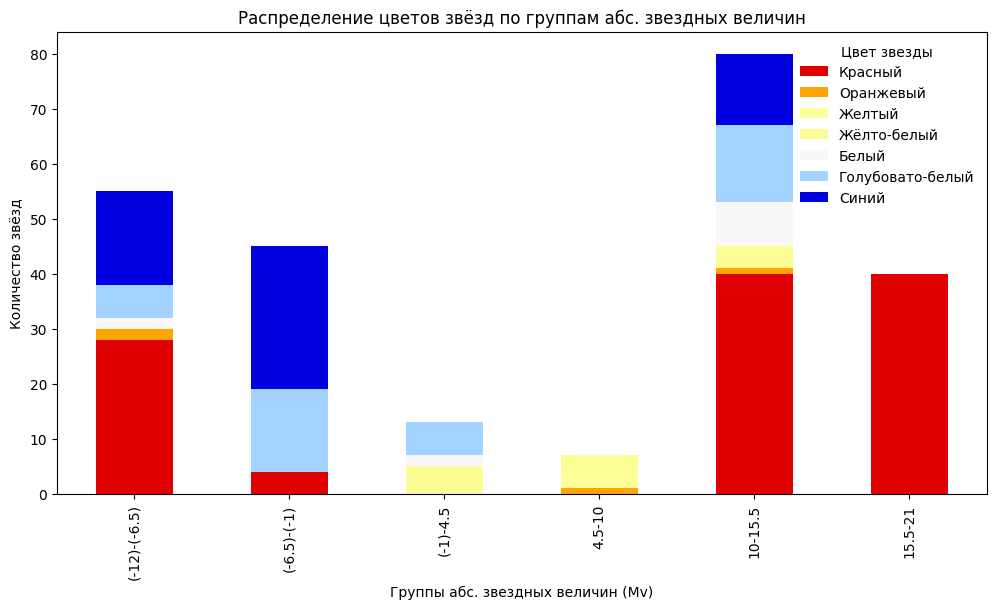

In [29]:
bins = [-12, -6.5, -1, 4.5, 10, 15.5, 21]
labels = ['(-12)-(-6.5)','(-6.5)-(-1)','(-1)-4.5','4.5-10','10-15.5','15.5-21']

df_rus['Mv группа'] = pd.cut(df_rus['Абсолютная звёздная величина (Mv)'], bins=bins, labels=labels, include_lowest=True)

grouped = df_rus.groupby(['Mv группа', 'Цвет звезды']).size().unstack(fill_value=0)
grouped = grouped[color_to_class.loc[grouped.columns].sort_values().index]

grouped.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)
plt.xlabel('Группы абс. звездных величин (Mv)')
plt.ylabel('Количество звёзд')
plt.title('Распределение цветов звёзд по группам абс. звездных величин')
plt.legend(title='Цвет звезды', frameon=False)
plt.show()

Построим диаграмму спектральный класс светимость и сравним ее с диаграммой Герцшпрунга — Рассела, которая представляет зависимость между абсолютной звёздной величиной и спектральным классом для звёзд, либо между другими величинами (например светимостью), которые тесно связаны с этими параметрами.

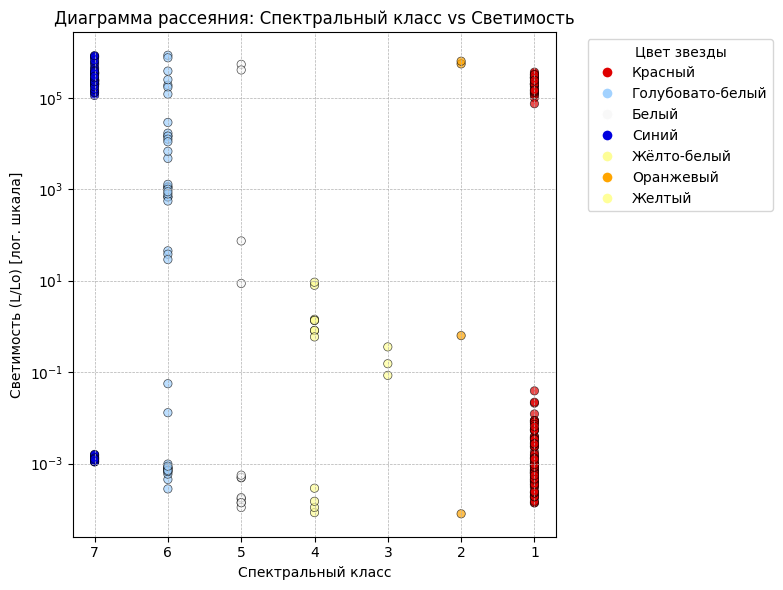

In [30]:
# Строим scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(
    df_rus['Спектральный класс'],
    df_rus['Светимость (L/Lo)'],
    c=df_rus['Цвет звезды'].map(color_palette),
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Логарифмическая шкала для светимости
plt.yscale('log')

# Инвертируем ось X (по убыванию спектрального класса)
plt.gca().invert_xaxis()

# Подписи
plt.xlabel('Спектральный класс')
plt.ylabel('Светимость (L/Lo) [лог. шкала]')
plt.title('Диаграмма рассеяния: Спектральный класс vs Светимость')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Легенда
handles = [plt.Line2D([0], [0], marker='o', color='w', label=color,
                      markerfacecolor=color_palette[color], markersize=8)
           for color in color_palette.keys()]
plt.legend(handles=handles, title='Цвет звезды', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Для сравнения приведем диаграмму Герцшпрунга — Рассела.

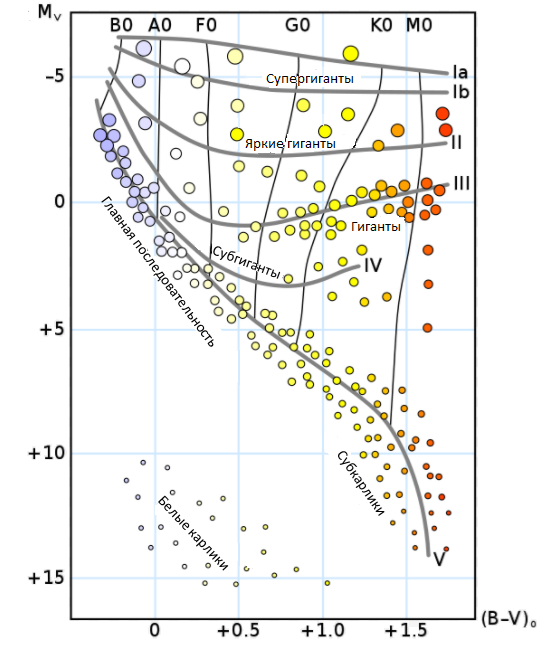

Построим точечный график зависимости Абсолютной звёздной величины от Типа звезды с разбивкой по Цвету звезды.

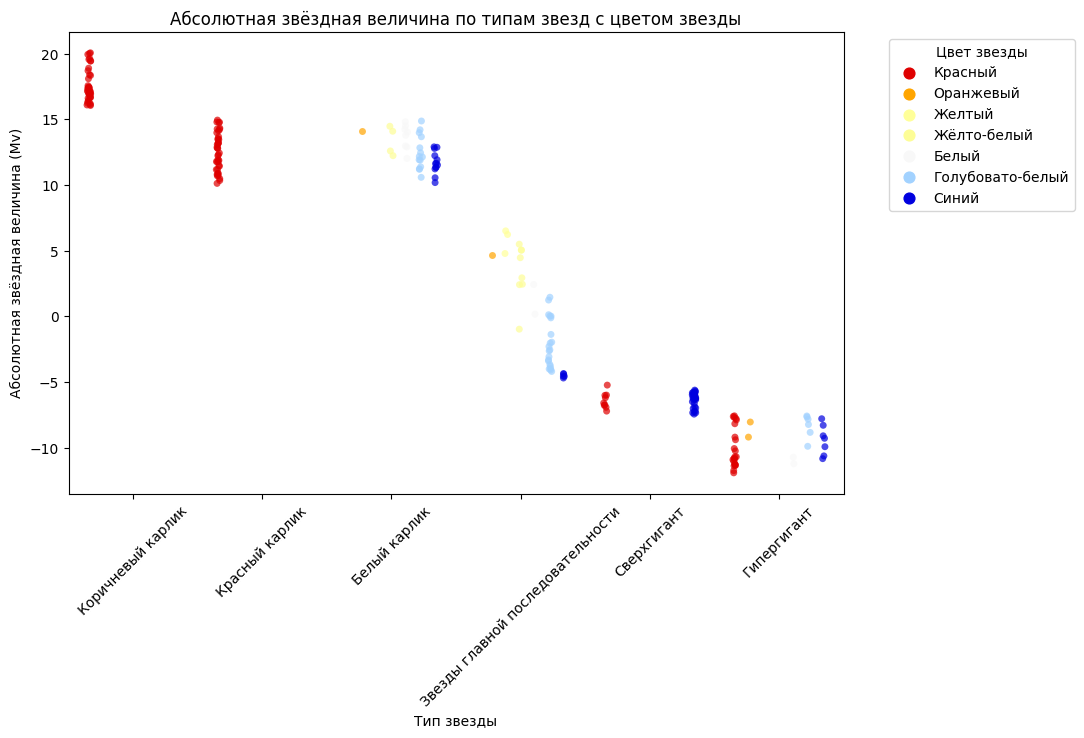

In [31]:
df_sorted = df_rus.sort_values(by='Спектральный класс')

plt.figure(figsize=(10,6))
sns.stripplot(
    data=df_sorted,
    x='Тип звезды',
    y='Абсолютная звёздная величина (Mv)',
    hue='Цвет звезды',
    palette=color_palette,
    dodge=True, alpha=0.7
)
plt.xlabel('Тип звезды')
plt.ylabel('Абсолютная звёздная величина (Mv)')
plt.title('Абсолютная звёздная величина по типам звезд с цветом звезды')
plt.xticks(rotation=45)
plt.legend(title='Цвет звезды', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Промежуточный итог:**

В ходе проведения исследовательского анализа данных был проведен статистический анализ и визуализация распределения данных. 

Оценена взаимосвязь цвета звезды с другими признаками.

Распределение цветов звёзд по температурным группам подтверждает закон Вина, который говорит, что чем выше температура тела, тем короче длина волны излучения и тем смещённее спектр в сторону синего.

Распределение цветов звёзд по типам звезд показывает, что есть общее правило смещения спектра в сторону синего цвета при увеличении размеров звезды. Однако среди сверхгигантов и гипергигантов также встречаются звезды других цветов. 

Зависимость светимости от спектрального класса повторяет диаграмму Герцшпрунга — Рассела. Это говорит о том, что данные корректны, и их распределение соответствует астрономическим законам.

График зависимости Абсолютной звёздной величины от Типа звезды с разбивкой по Цвету звезды показал, что каждому типу звезд соответствует свой диапазон абсолютных звездных величин. Пересекаются только диапазоны красного и белого карлика, Но в данном случае тип звезды определяется ее цветом. Таким образом, зная цвет звезды и ее абсолютную звёздную величину, можно точно определить тип звезды. Для исключения мультиколинеарности можно убрать признак "Тип звезды" из обучающей выборки.

<a class='anchor' id="link5"></a>
## 5 Корреляционный анализ

In [32]:
#количественные непрерывные признаки
num_continuous_features = rus_num_features+[rus_target_feature]

**5.1  Диаграмма рассеяния**

Для визуального анализа взаимосвязей между количественными признаками построим диаграмму рассеяния. Раскрасим точки в соответствии с цветом звезды.

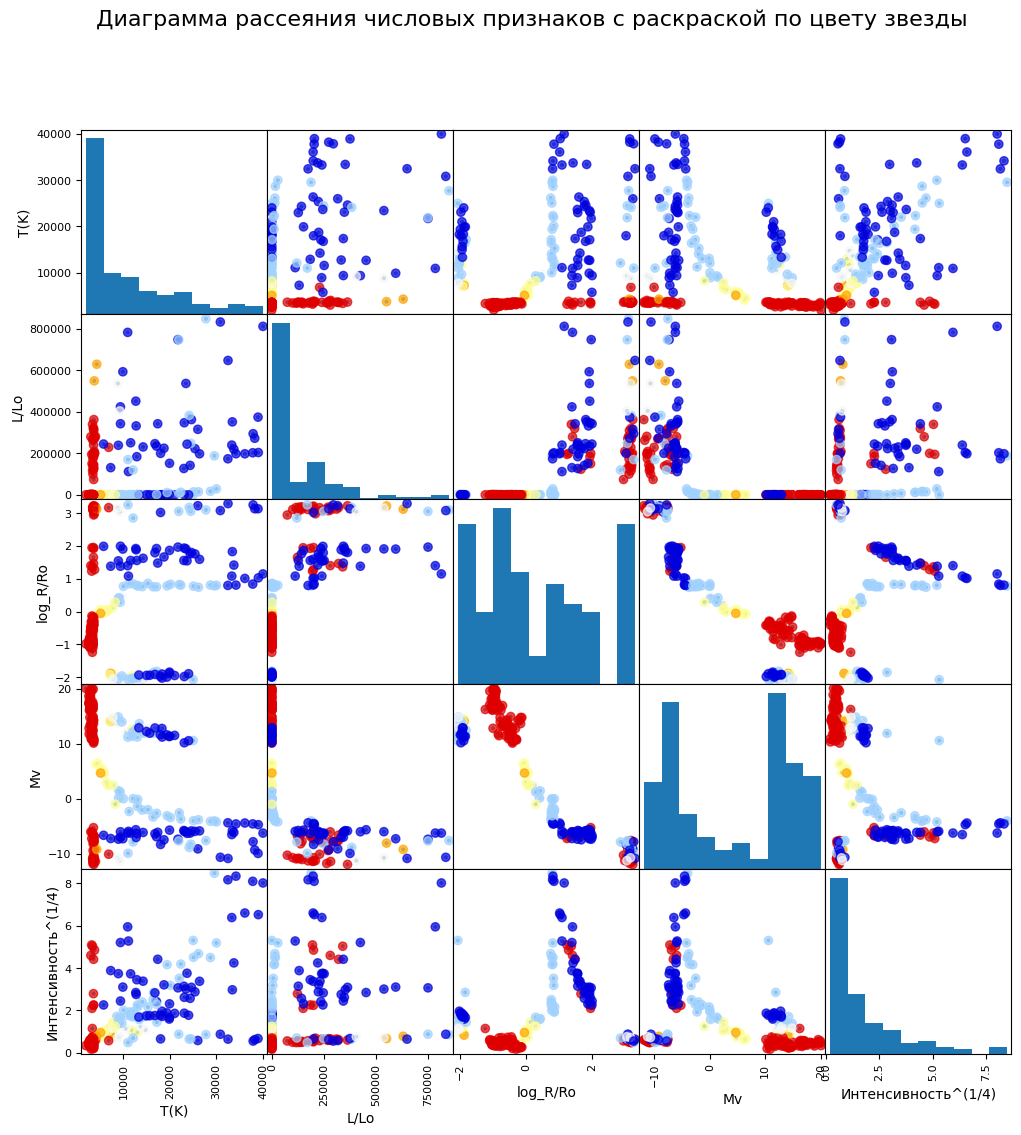

In [33]:
# Переименуем признаки, чтобы названия столбцов не пересекались на диаграмме
df_rus_renamed = df_rus.rename(columns={
    'Температура (K)': 'T(K)',
    'Интенсивность излучения (в 1/4 степени)': 'Интенсивность^(1/4)',
    'Светимость (L/Lo)': 'L/Lo',
    'Радиус (R/Ro)': 'R/Ro',
    'Абсолютная звёздная величина (Mv)': 'Mv'
})

# Создаём признак Радиус в логарифмическом масштабе
df_rus_renamed['log_R/Ro'] = np.log10(df_rus_renamed['R/Ro'])

# Выбираем числовые признаки
features = ['T(K)', 'L/Lo', 'log_R/Ro', 'Mv', 'Интенсивность^(1/4)']

# Цвета точек по звёздам
colors = df_rus['Цвет звезды'].map(color_palette)

# Строим scatter_matrix
axes = scatter_matrix(df_rus_renamed[features], figsize=(12, 12), diagonal='hist', alpha=0.7)

# Перекрашиваем точки в каждой диагонали
for i in range(len(features)):
    for j in range(len(features)):
        if i != j:
            axes[i, j].scatter(df_rus_renamed[features[j]], df_rus_renamed[features[i]], c=colors, alpha=0.7)

plt.suptitle("Диаграмма рассеяния числовых признаков с раскраской по цвету звезды", fontsize=16)

plt.show()

На части диапазона наблюдается обратнопропорциональная зависимость между абсолютной звёздной величиной и температурой. Прослеживается слабая линейная зависимость между темпрературой и корнем 4й степени из интенсивности.

За исключением шумов, можно сказать, что радиус в логарифмическом масштабе имеет прямую зависимоть с температурой и светимостью.

Имеется обратнопропрорциональная зависимоть между абсолютной звёздной величиной и радиусом в логарифмическом масштабе.

Между радиусом в логарифмическом масштабе и интенсивностью излучения в 1/4 степени на половине диапазона прямая зависимоть, на второй половине обратная.

Звезды с радиусами в диапазоне примерно от 0,1 R/R0 до 1 R/R0 не имеют температуры выше примерно 5000 К. 

Звезды с радиусами примерно до 10 R/R0 имеют минимальную светимость.

**5.2 Матрица корреляции Phik**

Для базовой регрессии нейросеть лучше учится, если признаки и целевая переменная имеют хорошую линейную или почти линейную зависимость.

Для оценки корреляций категориальных признаков используем матрицу корреляций Phik.

Для оценки линейных связей между количественными признаками посчитаем матрицу корреляции Пирсона.

In [34]:
drop_columns = ['Темп. группа', 'Светимость группа', 'Радиус группа', 'Mv группа']

# Вычисляем матрицу корреляции Phik
corr_matrix_phik = df_rus.drop(columns=drop_columns).phik_matrix(interval_cols=num_continuous_features)

# Выводим матрицу
corr_matrix_phik

,Температура (K),Светимость (L/Lo),Радиус (R/Ro),Абсолютная звёздная величина (Mv),Тип звезды,Цвет звезды,Спектральный класс,Интенсивность излучения (в 1/4 степени),Радиус (log(R/Ro))
Температура (K),1.000000,0.562667,0.236637,0.710472,0.603924,0.713357,0.713357,0.702742,0.962406
Светимость (L/Lo),0.562667,1.000000,0.574964,0.709456,0.654026,0.429520,0.429520,0.460207,0.000000
Радиус (R/Ro),0.236637,0.574964,1.000000,0.512414,0.635115,0.091675,0.091675,0.000000,1.000000
Абсолютная звёздная величина (Mv),0.710472,0.709456,0.512414,1.000000,0.915921,0.696759,0.696759,0.655848,0.998829
Тип звезды,0.603924,0.654026,0.635115,0.915921,1.000000,0.665739,0.665739,0.780716,0.999603
Цвет звезды,0.713357,0.429520,0.091675,0.696759,0.665739,1.000000,1.000000,0.593268,0.986767
Спектральный класс,0.713357,0.429520,0.091675,0.696759,0.665739,1.000000,1.000000,0.593268,0.986767
Интенсивность излучения (в 1/4 степени),0.702742,0.460207,0.000000,0.655848,0.780716,0.593268,0.593268,1.000000,0.436611
Радиус (log(R/Ro)),0.962406,0.000000,1.000000,0.998829,0.999603,0.986767,0.986767,0.436611,1.000000


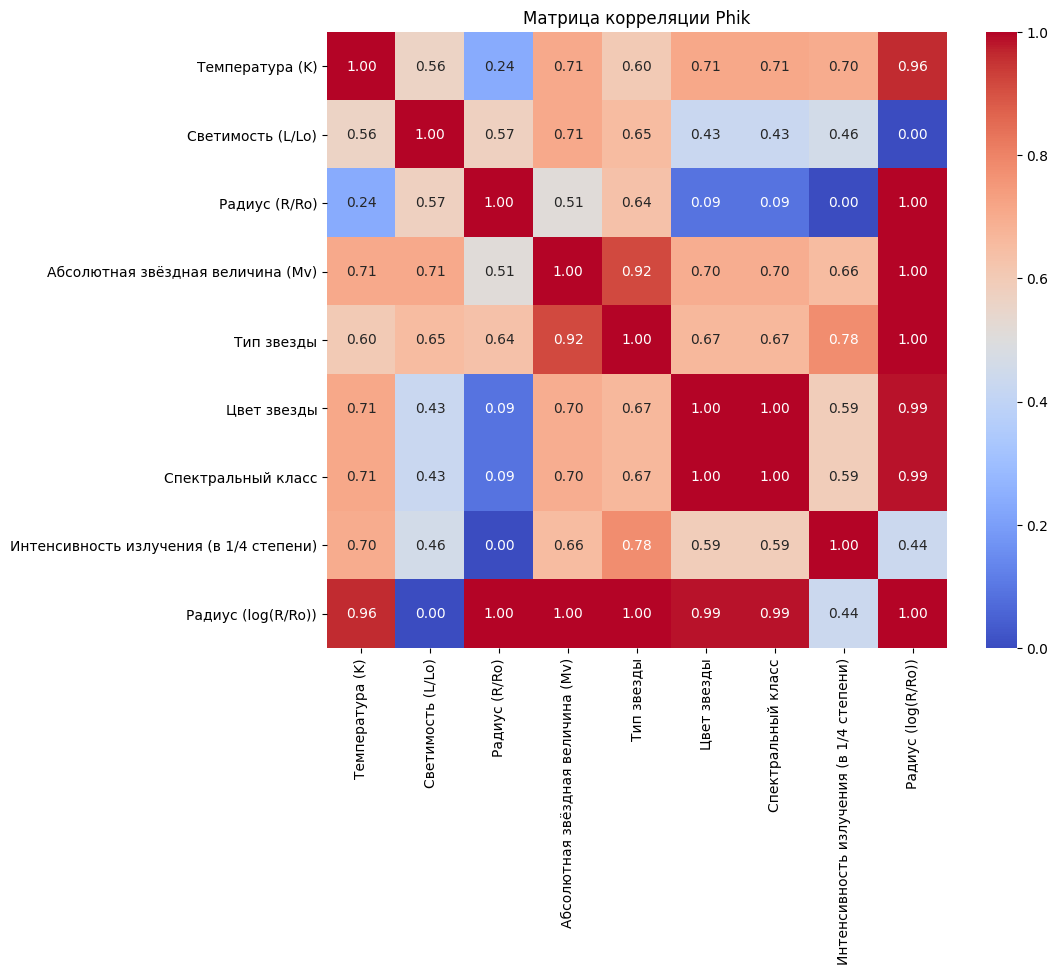

In [35]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_phik, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляции Phik")
plt.show()

In [36]:
print_corr_levels(corr_matrix_phik, threshold = 0.5)

[('Весьма высокая корреляция между Радиус (R/Ro) и Радиус (log(R/Ro)):', 1.0),
 ('Весьма высокая корреляция между Спектральный класс и Цвет звезды:', 1.0),
 ('Весьма высокая корреляция между Радиус (log(R/Ro)) и Тип звезды:', 1.0),
 ('Весьма высокая корреляция между Абсолютная звёздная величина (Mv) и Радиус (log(R/Ro)):',
  0.999),
 ('Весьма высокая корреляция между Радиус (log(R/Ro)) и Цвет звезды:', 0.987),
 ('Весьма высокая корреляция между Радиус (log(R/Ro)) и Спектральный класс:',
  0.987),
 ('Весьма высокая корреляция между Радиус (log(R/Ro)) и Температура (K):',
  0.962),
 ('Весьма высокая корреляция между Абсолютная звёздная величина (Mv) и Тип звезды:',
  0.916),
 ('Высокая корреляция между Интенсивность излучения (в 1/4 степени) и Тип звезды:',
  0.781),
 ('Высокая корреляция между Температура (K) и Цвет звезды:', 0.713),
 ('Высокая корреляция между Спектральный класс и Температура (K):', 0.713),
 ('Высокая корреляция между Абсолютная звёздная величина (Mv) и Температура (K)

Радиус в логарифмическом масштабе имеет весьма высокую корреляцию со всеми признаками кроме светимости.

Температура высоко коррелирует с абсолютной звёздной величиной, интенсивностью излучения (в 1/4 степени) и цветом звезды. 

Температура заметно коррелирует со светимостью и типом звезды.

Спектральный класс и Цвет звезды естественным образом имеют весьма высокую корреляцию и одинаково коррелируют с целевым признаком. Однако признак "Спектральный класс" имеет меньше категорий, что облегчит обучение модели. Поэтому признак "Цвет звезды" будет исключен из обучающего датасета.

Абсолютная звёздная величина (Mv) и Тип звезды имеют весьма высокую корреляцию. При этом по цвету звезды и ее абсолютной звёздной величине, можно точно определить тип звезды. Поэтому, для исключения мультиколинеарности, уберем признак "Тип звезды" из обучающей выборки.

**5.3 Матрица корреляции Пирсона**

In [37]:
# Вычисляем матрицу корреляции Пирсона
corr_matrix_pearson = df_rus.drop(columns=drop_columns).corr(method='pearson')

# Выводим матрицу
corr_matrix_pearson

,Температура (K),Светимость (L/Lo),Радиус (R/Ro),Абсолютная звёздная величина (Mv),Спектральный класс,Интенсивность излучения (в 1/4 степени),Радиус (log(R/Ro))
Температура (K),1.000000,0.393404,0.064216,-0.420261,0.809487,0.637200,0.212791
Светимость (L/Lo),0.393404,1.000000,0.526516,-0.692619,0.308138,0.317842,0.705692
Радиус (R/Ro),0.064216,0.526516,1.000000,-0.608728,-0.083006,-0.248452,0.747379
Абсолютная звёздная величина (Mv),-0.420261,-0.692619,-0.608728,1.000000,-0.381429,-0.428713,-0.911879
Спектральный класс,0.809487,0.308138,-0.083006,-0.381429,1.000000,0.582083,0.088151
Интенсивность излучения (в 1/4 степени),0.637200,0.317842,-0.248452,-0.428713,0.582083,1.000000,0.159921
Радиус (log(R/Ro)),0.212791,0.705692,0.747379,-0.911879,0.088151,0.159921,1.000000


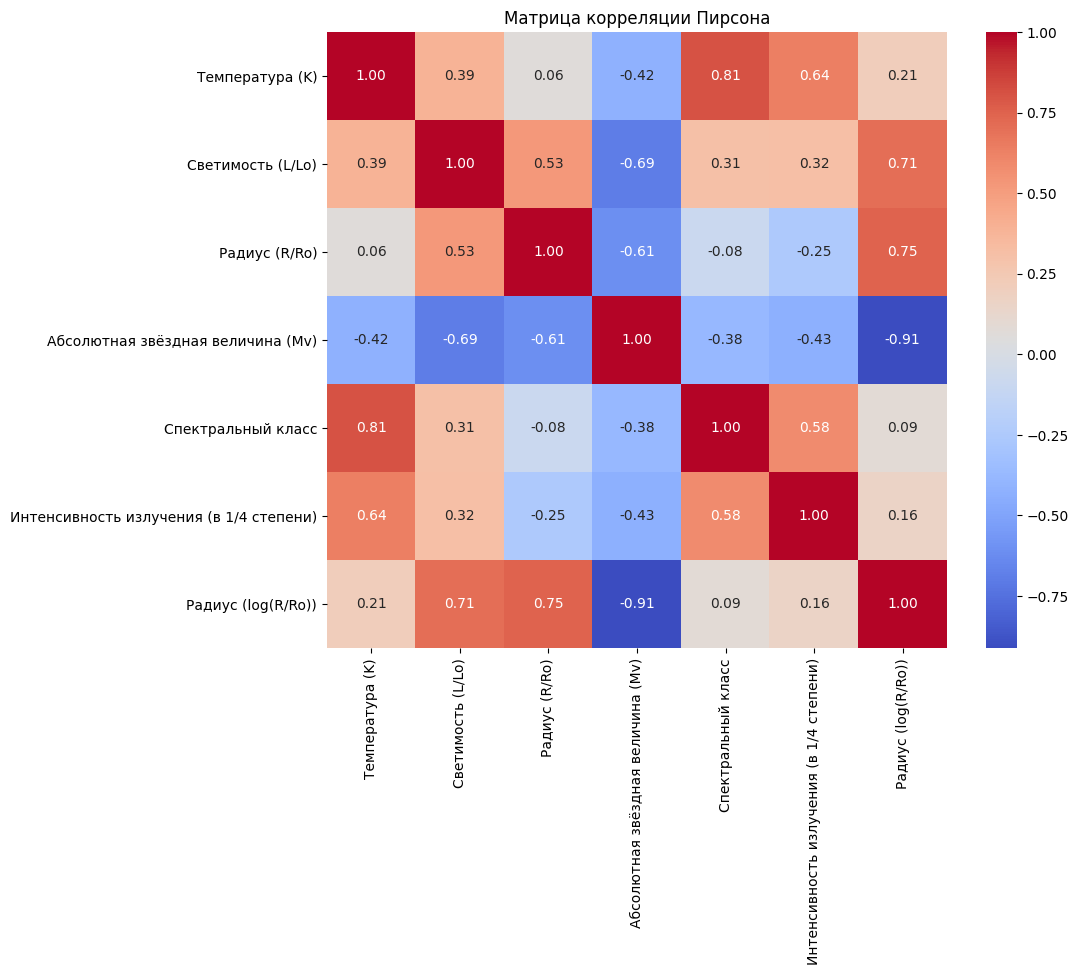

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_pearson, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляции Пирсона")
plt.show()

In [39]:
print_corr_levels(corr_matrix_pearson, threshold = 0.2)

[('Высокая корреляция между Спектральный класс и Температура (K):', 0.809),
 ('Высокая корреляция между Радиус (R/Ro) и Радиус (log(R/Ro)):', 0.747),
 ('Высокая корреляция между Радиус (log(R/Ro)) и Светимость (L/Lo):', 0.706),
 ('Заметная корреляция между Интенсивность излучения (в 1/4 степени) и Температура (K):',
  0.637),
 ('Заметная корреляция между Интенсивность излучения (в 1/4 степени) и Спектральный класс:',
  0.582),
 ('Заметная корреляция между Радиус (R/Ro) и Светимость (L/Lo):', 0.527),
 ('Умеренная корреляция между Светимость (L/Lo) и Температура (K):', 0.393),
 ('Умеренная корреляция между Интенсивность излучения (в 1/4 степени) и Светимость (L/Lo):',
  0.318),
 ('Умеренная корреляция между Светимость (L/Lo) и Спектральный класс:', 0.308),
 ('Слабая корреляция между Радиус (log(R/Ro)) и Температура (K):', 0.213),
 ('Слабая корреляция между Интенсивность излучения (в 1/4 степени) и Радиус (R/Ro):',
  -0.248),
 ('Умеренная корреляция между Абсолютная звёздная величина (Mv)

Температура имеет высокую корреляцию со спектральным классом (характеризующим цвет звезды).

Температура имеет заметную корреляцию с интенсивностью излучения (в 1/4 степени).

Температура имеет умеренную корреляцию со светимостью и абсолютной звездной величиной.

Радиус и температура имеют слабую корреляцию. Так как радиус уже использовался в формуле расчета интенсивности излучения, а также радиус имеет заметнуя обратнопропорциональную зависимость с абсолютной звёздной величиной, признаки Радиус (R/Ro) и Радиус (log(R/Ro)) можно убрать из обучающего датасета.

**Промежуточный итог:**

В ходе проведения корреляционного анализа были оценены взаимосязи между признаками. 

Сформированы предложения по формированию признаков для обучающего датасета. 

<a class='anchor' id="link6"></a>
## 6 Построение базовой нейронной сети

Для обучения нейросети будем использовать признаки Температура (K), Светимость (L/Lo), Абсолютная звёздная величина (Mv), Спектральный класс и Интенсивность излучения (в 1/4 степени).

In [40]:
# Список признаков для обучения
num_features = [
    'luminosity_l_lo',
    'absolute_magnitude_mv',
    'intensity_4r'
]

cat_features = [
    'spectral_class'
]

# Целевой признак
target_feature='temperature_k'

Красных звезд в выборке значительно больше, чем звезд других цветов. Учитывая, что температура звезды сильно коррелирует с ее цветом, мы можем получить модель, которая будет хорошо предсказывать температуры холодных звезд и плохо температуры горячих.

При разбиении на обучающую и тестовую выборки, проведем стратификацию по цвету звезды.

In [41]:
# Делим данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    df_prepared.drop(columns=[target_feature]),
    df_prepared[target_feature],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify=df_prepared['star_color']
)

In [42]:
# Выбираем необходимые признаки
df_prepared = df_prepared[num_features + cat_features + [target_feature]].copy()

Масштабируем числовые признаки через StandardScaler. Категориальные признаки закодируем через OHE.

In [43]:
# Трансформеры для разных типов признаков
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

# ColumnTransformer — применяет разные преобразования к разным колонкам
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Преобразуем train и test
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [44]:
# Конвертируем в тензоры для PyTorch
X_train_tensor = torch.tensor(X_train_prepared, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_prepared, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

Построение простой нейросети (Baseline)

In [45]:
# Класс нейросети
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons):
        super(Net, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(n_in_neurons, n_hidden_neurons_1),         # первый скрытый слой
            nn.LeakyReLU(),
            nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2),   # второй скрытый слой
            nn.LeakyReLU(),
            nn.Linear(n_hidden_neurons_2, n_out_neurons)         # выходной слой для регрессии
        )

    def forward(self, x):
        return self.model(x)

# Функция инициализации весов
def init_weights(layer):
    if isinstance(layer, nn.Linear):
        torch.manual_seed(SEED)
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.zeros_(layer.bias)

# Количество признаков
n_feat = X_train_tensor.shape[1]

# Создаем модель
net = Net(n_feat, 8, 5, 1)

net.apply(init_weights)

# Функция потерь и оптимизатор
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
loss = nn.MSELoss()

# Количество эпох
num_epochs = 10000

Epoch 1/10000 | Train RMSE: 18053.4708 | Test RMSE: 17367.5412
Epoch 101/10000 | Train RMSE: 8537.1311 | Test RMSE: 8988.1731
Epoch 201/10000 | Train RMSE: 6910.5166 | Test RMSE: 7771.7290
Epoch 301/10000 | Train RMSE: 6215.7545 | Test RMSE: 7160.5706
Epoch 401/10000 | Train RMSE: 5662.6836 | Test RMSE: 6684.5876
Epoch 501/10000 | Train RMSE: 5249.6545 | Test RMSE: 6385.7213
Epoch 601/10000 | Train RMSE: 4919.7799 | Test RMSE: 6104.1235
Epoch 701/10000 | Train RMSE: 4499.8498 | Test RMSE: 5820.4488
Epoch 801/10000 | Train RMSE: 4371.0278 | Test RMSE: 5646.5857
Epoch 901/10000 | Train RMSE: 4255.5949 | Test RMSE: 5486.6578
Epoch 1001/10000 | Train RMSE: 4150.7462 | Test RMSE: 5329.8343
Epoch 1101/10000 | Train RMSE: 4056.6040 | Test RMSE: 5170.6379
Epoch 1201/10000 | Train RMSE: 3958.4287 | Test RMSE: 5017.0593
Epoch 1301/10000 | Train RMSE: 3862.6720 | Test RMSE: 4872.6705
Epoch 1401/10000 | Train RMSE: 3752.2774 | Test RMSE: 4737.2591
Epoch 1501/10000 | Train RMSE: 3634.6575 | Test RM

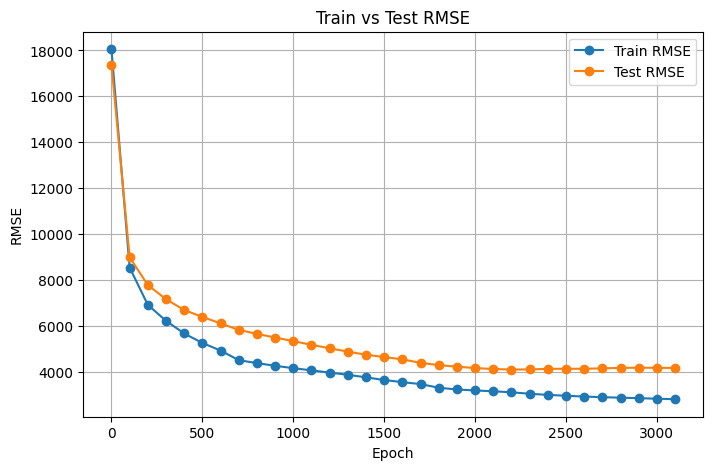

In [46]:
# Функция обучения
def train_model(model, X_train, y_train, X_test, y_test, num_epochs, patience=1000):

    history_train_rmse = []
    history_test_rmse = []
    epochs_list = []

    best_test_rmse = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        preds = model(X_train) 
        train_loss = loss(preds, y_train)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
                
            # Преобразуем предсказания обратно в исходный масштаб
            train_preds = scaler_y.inverse_transform(preds.detach().numpy())
            test_preds_scaled = model(X_test)
            test_preds = scaler_y.inverse_transform(test_preds_scaled.detach().numpy())
            y_train_original = scaler_y.inverse_transform(y_train.detach().numpy())
            y_test_original = scaler_y.inverse_transform(y_test.detach().numpy())

            # RMSE в исходном масштабе
            train_rmse = math.sqrt(((train_preds - y_train_original) ** 2).mean())
            test_rmse = math.sqrt(((test_preds - y_test_original) ** 2).mean())

            # Ранняя остановка
            if test_rmse < best_test_rmse:
                best_test_rmse = test_rmse
                epochs_no_improve = 0
                best_model_state = model.state_dict()  # сохраняем лучшую модель
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"Ранняя остановка на эпохе {epoch+1}. Лучший RMSE: {best_test_rmse:.4f}")
                    model.load_state_dict(best_model_state)  # восстанавливаем лучшую модель
                    break
                        
        if epoch % 100 == 0 or epoch == num_epochs - 1:
            history_train_rmse.append(train_rmse)
            history_test_rmse.append(test_rmse)
            epochs_list.append(epoch + 1)
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
            

    # Построение графика
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_list, history_train_rmse, marker='o', label='Train RMSE')
    plt.plot(epochs_list, history_test_rmse, marker='o', label='Test RMSE')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.title('Train vs Test RMSE')
    plt.legend()
    plt.grid(True)
    plt.show()

# Обучаем модель
train_model(net, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, num_epochs)

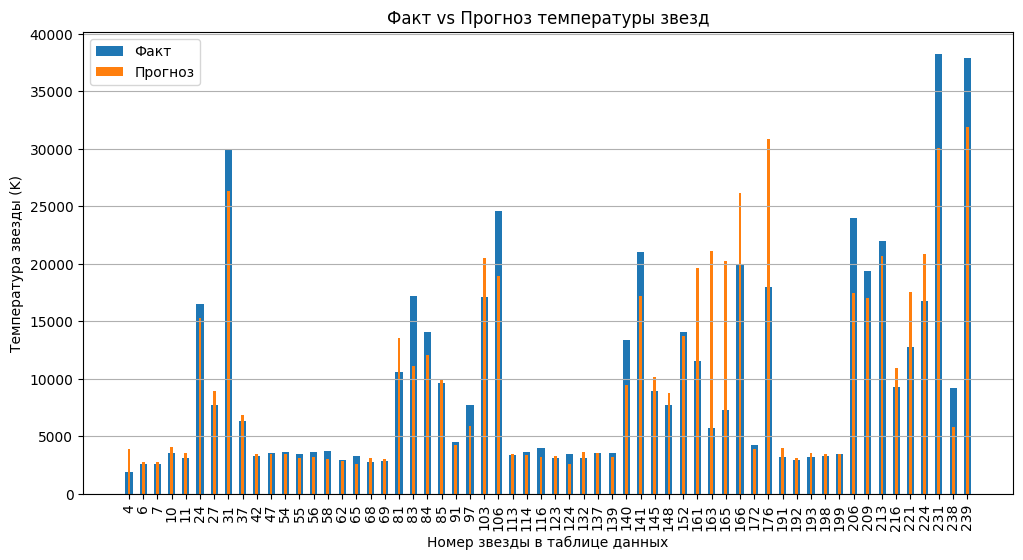

In [47]:
# Переводим модель в режим оценки
net.eval()
with torch.no_grad():
    y_pred_tensor = net(X_test_tensor)

# Преобразуем тензоры в numpy
y_test_np = y_test_tensor.numpy()
y_pred_np = y_pred_tensor.numpy()

# Обратно в исходный масштаб
y_test_original = scaler_y.inverse_transform(y_test_np).flatten()
y_pred_original = scaler_y.inverse_transform(y_pred_np).flatten()

# Создаем DataFrame
df_plot = pd.DataFrame({
    'star_number': y_test.index,   # номера звезд
    'y_true': y_test_original,
    'y_pred': y_pred_original
})

# Сортируем по номеру звезды
df_plot = df_plot.sort_values('star_number').reset_index(drop=True)

# Преобразуем номер звезды в строку (чтобы не было пропусков в графике)
df_plot['star_number'] = df_plot['star_number'].astype(str)

# Строим график
plt.figure(figsize=(12, 6))
plt.bar(df_plot['star_number'], df_plot['y_true'], width=0.5, label='Факт', alpha=1)
plt.bar(df_plot['star_number'], df_plot['y_pred'], width=0.2, label='Прогноз', alpha=1)
plt.xlabel('Номер звезды в таблице данных')
plt.ylabel('Температура звезды (K)')
plt.title('Факт vs Прогноз температуры звезд')
plt.xticks(df_plot['star_number'], rotation=90)
plt.legend()
plt.grid(axis='y')
plt.show()

**Промежуточный итог:**

График демонстрирует более высокую точность предсказания температур для более холодных звезд. Имеются несколько звезд с большими ошибками определения температуры.

Обученная нейронная сеть имеет RMSE на тестовых данных 4080, что удовлетворяет целевому показателю RMSE < 4500.

При данных параметрах модели оптимальное количество эпох обучения примерно 2000-3000. После 2200 эпох RMSE на тестовых данных практически не улучшается, а RMSE  на тренировочных данных продолжает ученьшаться, модель начинает переобучаться.

Попробуем улучшить предсказательную способность нейросети использованием Dropout.

<a class='anchor' id="link7"></a>
## 7 Улучшение нейронной сети

Добавим в базовую модель регулярицазию Dropout. Также теперь будем подавать данные частями (батчами)

In [48]:
# Класс нейросети
class NetDropout(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons, dropout=0.0):
        super(NetDropout, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(n_in_neurons, n_hidden_neurons_1),         # первый скрытый слой
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2),   # второй скрытый слой
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden_neurons_2, n_out_neurons)         # выходной слой для регрессии
        )

    def forward(self, x):
        return self.model(x)

# Функция инициализации весов
def init_weights(layer):
    if isinstance(layer, nn.Linear):
        torch.manual_seed(SEED)
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.zeros_(layer.bias)

In [49]:
def train_one_model_dropout(dropout, batch_size, num_epochs):

    # Создаем модель
    net = NetDropout(n_feat, 8, 5, 1, dropout)
    net.apply(init_weights)
    
    # Функция потерь и оптимизатор
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-2)
    loss = nn.MSELoss()

    # DataLoader
    train_dataset = data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(num_epochs):
        net.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = net(X_batch)
            train_loss = loss(preds, y_batch)
            train_loss.backward()
            optimizer.step()

    # Оценка на train и test
    net.eval()
    with torch.no_grad():
        train_preds = net(X_train_tensor).detach().numpy()
        test_preds = net(X_test_tensor).detach().numpy()
        y_train_np = y_train_tensor.detach().numpy()
        y_test_np = y_test_tensor.detach().numpy()

        train_preds = scaler_y.inverse_transform(train_preds)
        test_preds = scaler_y.inverse_transform(test_preds)
        y_train_np = scaler_y.inverse_transform(y_train_np)
        y_test_np = scaler_y.inverse_transform(y_test_np)

        # RMSE для train и test
        train_rmse = math.sqrt(((y_train_np - train_preds) ** 2).mean())
        test_rmse = math.sqrt(((y_test_np - test_preds) ** 2).mean())

        print(f"Dropout {dropout} | Batch Size {batch_size} | "
              f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
        
    return train_rmse, test_rmse, net

In [50]:
# Количество эпох
num_epochs = 2000

# Список параметров для перебора
dropout_list = [0.0, 0.2, 0.4]
batch_size_list = [4, 8, 16, 32, 64]

# Словарь для хранения результатов
results = []

In [51]:
# Перебор всех сочетаний
for dropout in dropout_list:
    for batch_size in batch_size_list:
        train_rmse, test_rmse, model = train_one_model_dropout(dropout, batch_size, num_epochs)
        results.append({
            'dropout': dropout,
            'batch_size': batch_size,
            'train_rmse': train_rmse,
            'test_rmse': test_rmse
        })

# Преобразуем результаты в DataFrame для удобного анализа
results_df = pd.DataFrame(results)

Dropout 0.0 | Batch Size 4 | Train RMSE: 1845.6196 | Test RMSE: 4982.8231
Dropout 0.0 | Batch Size 8 | Train RMSE: 1726.9136 | Test RMSE: 5236.1665
Dropout 0.0 | Batch Size 16 | Train RMSE: 2297.1223 | Test RMSE: 4301.9365
Dropout 0.0 | Batch Size 32 | Train RMSE: 1920.0313 | Test RMSE: 3904.7668
Dropout 0.0 | Batch Size 64 | Train RMSE: 2353.6729 | Test RMSE: 3753.3087
Dropout 0.2 | Batch Size 4 | Train RMSE: 3941.7202 | Test RMSE: 4445.7269
Dropout 0.2 | Batch Size 8 | Train RMSE: 3923.3846 | Test RMSE: 4316.5530
Dropout 0.2 | Batch Size 16 | Train RMSE: 3815.0654 | Test RMSE: 4196.6296
Dropout 0.2 | Batch Size 32 | Train RMSE: 3937.5167 | Test RMSE: 4373.8089
Dropout 0.2 | Batch Size 64 | Train RMSE: 3963.4278 | Test RMSE: 4468.0497
Dropout 0.4 | Batch Size 4 | Train RMSE: 5225.0788 | Test RMSE: 5442.8689
Dropout 0.4 | Batch Size 8 | Train RMSE: 4751.6174 | Test RMSE: 4920.0713
Dropout 0.4 | Batch Size 16 | Train RMSE: 4574.7391 | Test RMSE: 4771.4310
Dropout 0.4 | Batch Size 32 | T

In [52]:
print("Параметры и метрики лучшей модели")
best_model = results_df.sort_values('test_rmse').iloc[0]  # берем первую строку как Series
print(f"Dropout={best_model['dropout']}, Batch_size={best_model['batch_size']} | "
      f"Train RMSE={best_model['train_rmse']:.4f} | Test RMSE={best_model['test_rmse']:.4f}")

Параметры и метрики лучшей модели
Dropout=0.0, Batch_size=64.0 | Train RMSE=2353.6729 | Test RMSE=3753.3087


Dropout 0.0 | Batch Size 64 | Train RMSE: 2353.6729 | Test RMSE: 3753.3087


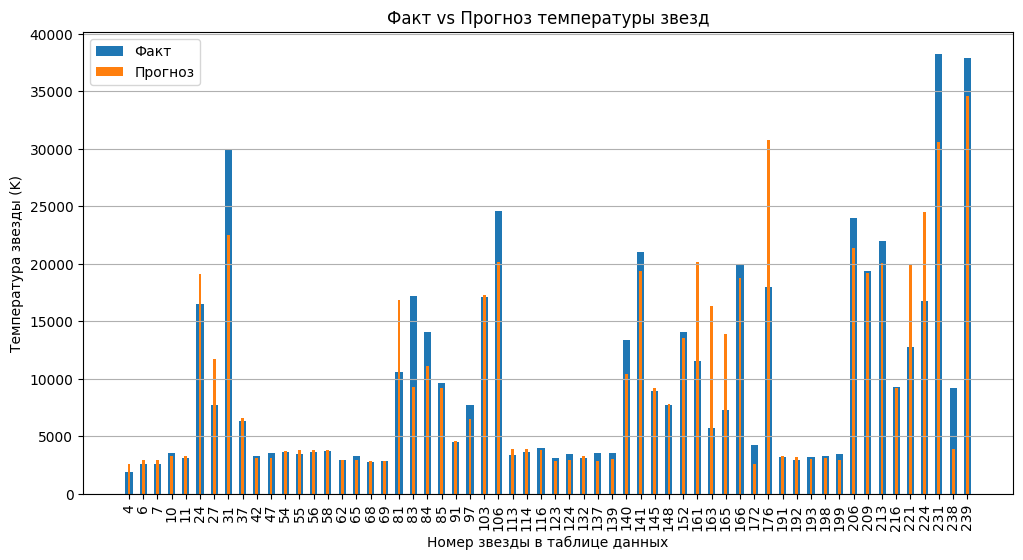

In [53]:
train_rmse, test_rmse, best_model = train_one_model_dropout(float(best_model['dropout']), int(best_model['batch_size']), num_epochs)
best_model.eval()

with torch.no_grad():
    y_pred_tensor = best_model(X_test_tensor)

# Преобразуем тензоры в numpy
y_test_np = y_test_tensor.numpy()
y_pred_np = y_pred_tensor.numpy()

# Обратно в исходный масштаб
y_test_original = scaler_y.inverse_transform(y_test_np).flatten()
y_pred_original = scaler_y.inverse_transform(y_pred_np).flatten()

# Создаем DataFrame
df_plot = pd.DataFrame({
    'star_number': y_test.index,   # номера звезд
    'y_true': y_test_original,
    'y_pred': y_pred_original
})

# Сортируем по номеру звезды
df_plot = df_plot.sort_values('star_number').reset_index(drop=True)

# Преобразуем номер звезды в строку (чтобы не было пропусков в графике)
df_plot['star_number'] = df_plot['star_number'].astype(str)

# Строим график
plt.figure(figsize=(12, 6))
plt.bar(df_plot['star_number'], df_plot['y_true'], width=0.5, label='Факт', alpha=1)
plt.bar(df_plot['star_number'], df_plot['y_pred'], width=0.2, label='Прогноз', alpha=1)
plt.xlabel('Номер звезды в таблице данных')
plt.ylabel('Температура звезды (K)')
plt.title('Факт vs Прогноз температуры звезд')
plt.xticks(df_plot['star_number'], rotation=90)
plt.legend()
plt.grid(axis='y')
plt.show()

**Промежуточный итог:**

График демонстрирует более высокую точность предсказания температур для более холодных звезд. Имеются несколько относительно горячих звезд с большими ошибками определения температуры.

Был проведён перебор значений Dropout и размера батча. Введение Dropout не дало улучшения метрик модели. Лучшей оказалась нейросеть с Dropout=0.0 и размером батча 64. RMSE на тестовой выборке составила 3753.

<a class='anchor' id="link8"></a>
## Общий вывод

**Целью проекта** было разработать нейросетевую модель для предсказания абсолютной температуры звёзд на основе их физических и наблюдательных характеристик, предоставленных обсерваторией «Небо на ладони».

**В ходе работ:**
* Проведена предобработка данных, включая масштабирование и кодирование признаков.
* Созданы новые признаки, отражающие характеристики звезд.
* Выполнен исследовательский анализ данных, визуализированы распределения и зависимости.
* Проведен корреляционный анализ, выбраны наиболее важные признаки для модели.
* Обучены нейросети с различными параметрами.

**Результаты:**

Для достижения целевого RMSE < 4500 были протестированы разные комбинации признаков, методы масштабирования и кодирования.

Наилучшую метрику RMSE = 4080 показала нейросеть с двумя скрытыми слоями и функцией активации LeakyReLU.

Для уменьшения переобучения использовались L2-регуляризация в оптимизаторе Adam и Dropout. Проведен перебор Dropout и размера батча.
Введение Dropout не улучшило метрики модели. Наилучшей моделью оказалась нейросеть с Dropout=0.0, и размером батча 64.0. RMSE на тестовой выборке 3753.

Исследование литературы по теме определения температур звезд показало, что существует большое количество факторов, влияющих на нелинейные взаимосвязи параметров звезд с их температурой.

Для улучшения предсказательной способности модели **рекомендуется**:
* Увеличить объём данных.
* Ввести новые признаки, например:
    * результаты спектрального анализа с длинами волн основного потока излучения
    * расстояния до звезд, для оценки эффекта доплера, и т.д.
* Проводить дальнейший подбор нейросетей для поиска наиболее удачных архитектур.